# ScoreMatch  
## Classical Composer Identification Using MIDI and Deep Learning

ScoreMatch is a music-classification project designed to identify the composer of a classical MIDI file. The system analyzes works from Bach, Beethoven, Chopin, and Mozart using extracted musical features and piano-roll representations. The project compares traditional machine-learning baselines with deep-learning models, including a Convolutional Neural Network (CNN) and a CNN-LSTM, to determine which approach provides the strongest composer-classification performance.

The complete workflow includes MIDI data collection, feature extraction, balanced dataset preparation, piano-roll generation at 20 frames per second, model training, test-set evaluation, and performance visualization.

### Team 4 Members and Roles

- **Nicholson Alforque: Data Collection and Feature Extraction**  
  Collected and organized the MIDI dataset, processed the MIDI files, and extracted numerical musical features such as tempo, pitch, note duration, velocity, intervals, instrumentation, note density, and pitch-class distributions.

- **Thomas Geraci: Deep-Learning Model Development and Training**  
  Prepared the balanced training, validation, and testing datasets; generated 20 FPS piano-roll inputs; developed the CNN and CNN-LSTM architectures; trained the models; applied validation and early stopping; and exported the final test predictions and model results.

- **Cameron Aljilani: Model Evaluation and Performance Analysis**  
  Evaluated the final model predictions, created confusion matrices and performance visualizations, compared composer-level results, and analyzed which composers were most frequently confused by the models.

## Nicholson Alforque: Data Collection and Feature Extraction

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Install the required ScoreMatch packages in the current Google Colab runtime.
%pip install -q --disable-pip-version-check pretty_midi joblib

In [ ]:
# This notebook is using Python ver. 3.10+

import os
import json
import random
import time
import copy
import warnings
from functools import lru_cache
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch # main lib
import torch.nn as nn # neural network
import torch.optim as optim # optimization
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

import pretty_midi
import joblib

# Some MIDI files contain nonstandard metadata. The extraction function below
# catches unreadable files and skips them without stopping the notebook.
warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    module="pretty_midi"
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch version:", torch.__version__)
print("pretty_midi version:", pretty_midi.__version__)

PyTorch version: 2.11.0+cu128
pretty_midi version: 0.2.11.post0


In [ ]:
# -----------------------------------------------------------------------------
# DATASET LOCATION AND CONTROLLED SAMPLE SIZE — GOOGLE COLAB
#
# Upload archive.zip through the Colab Files panel.
#
# Required ZIP structure:
#
# archive.zip
# └── archive/
#     ├── Bach/
#     ├── Beethoven/
#     ├── Chopin/
#     └── Mozart/
#
# The ZIP may also contain the four composer folders directly without the
# outer archive folder. This cell supports either structure.
# -----------------------------------------------------------------------------

!pip install -q --disable-pip-version-check pretty_midi joblib

import os
import zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import random
from collections import Counter
import pretty_midi
import warnings

# Some MIDI files contain nonstandard metadata. The extraction function below
# catches unreadable files and skips them without stopping the notebook.
warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    module="pretty_midi"
)


EXPECTED_COMPOSERS = {
    "bach",
    "beethoven",
    "chopin",
    "mozart",
}


# -----------------------------------------------------------------------------
# TEAM MEMBER CONFIGURATION
# ------------------------------------------------------------------------------
# Each team member should upload archive.zip through the Colab Files panel.
#
# The uploaded file normally appears here:
DATASET_ZIP_PATH = Path("/content/archive.zip")

# Files will be extracted into this temporary Colab folder.
EXTRACTION_DIRECTORY = Path("/content/scorematch_data")

# Optional manual override:
# Set this to a dataset folder only when the dataset is already extracted
# USER_DATASET_DIRECTORY = "/content/archive"
USER_DATASET_DIRECTORY = None


#The controlled experiment uses exactly 136 valid MIDI files per composer.
FILES_PER_COMPOSER = int(
    os.environ.get(
        "SCOREMATCH_FILES_PER_COMPOSER",
        "136",
    )
)

FAST_RUN = (
    os.environ.get("SCOREMATCH_FAST_RUN", "0") == "1"
)

MAX_FILES_PER_COMPOSER = FILES_PER_COMPOSER

def safe_stat(values, statistic="mean", default=0.0):
    """
    Safely calculate a statistic from a list or NumPy array.
    """
    values = np.asarray(values, dtype=float)

    if values.size == 0:
        return default

    if statistic == "mean":
        return float(np.mean(values))
    elif statistic == "std":
        return float(np.std(values))
    elif statistic == "min":
        return float(np.min(values))
    elif statistic == "max":
        return float(np.max(values))
    elif statistic == "median":
        return float(np.median(values))

    raise ValueError(f"Unsupported statistic: {statistic}")

def extract_midi_features(file_path):
    """
    Extract file-level musical features from one MIDI file.
    """
    try:
        midi = pretty_midi.PrettyMIDI(str(file_path))
    except Exception as error:
        print(f"Could not read {file_path}: {error}")
        return None

    pitches = []
    velocities = []
    durations = []
    start_times = []
    pitch_classes = []
    intervals = []

    instrument_programs = []
    melodic_track_count = 0
    drum_track_count = 0

    for instrument in midi.instruments:
        instrument_programs.append(instrument.program)

        if instrument.is_drum:
            drum_track_count += 1
        else:
            melodic_track_count += 1

        instrument_notes = sorted(
            instrument.notes,
            key=lambda note: note.start
        )

        previous_pitch = None

        for note in instrument_notes:
            duration = max(0.0, note.end - note.start)

            pitches.append(note.pitch)
            velocities.append(note.velocity)
            durations.append(duration)
            start_times.append(note.start)
            pitch_classes.append(note.pitch % 12)

            if previous_pitch is not None:
                intervals.append(abs(note.pitch - previous_pitch))

            previous_pitch = note.pitch

    if len(pitches) == 0:
        return None

    #Estimates the tempo.
    try:
        tempo = float(midi.estimate_tempo())
    except Exception:
        tempo = 0.0

    #MIDI duration in seconds.
    total_duration = float(midi.get_end_time())

    #Number of notes per second.
    note_density = (
        len(pitches) / total_duration
        if total_duration > 0
        else 0.0
    )

    #Pitch range.
    pitch_range = max(pitches) - min(pitches)

    #Pitch-class distribution: C, C#, D, ..., B.
    pitch_class_counts = Counter(pitch_classes)
    pitch_class_total = max(1, len(pitch_classes))

    pitch_class_features = {
        f"pitch_class_{pitch_class}":
            pitch_class_counts.get(pitch_class, 0) / pitch_class_total
        for pitch_class in range(12)
    }

    #Percentage of notes that overlap another note.
    sorted_notes = []

    for instrument in midi.instruments:
        if instrument.is_drum:
            continue

        sorted_notes.extend(instrument.notes)

    sorted_notes = sorted(sorted_notes, key=lambda note: note.start)

    overlapping_notes = 0
    previous_end = -np.inf

    for note in sorted_notes:
        if note.start < previous_end:
            overlapping_notes += 1

        previous_end = max(previous_end, note.end)

    polyphony_rate = (
        overlapping_notes / len(sorted_notes)
        if len(sorted_notes) > 0
        else 0.0
    )

    #Time-signature information.
    time_signatures = midi.time_signature_changes

    if time_signatures:
        first_numerator = time_signatures[0].numerator
        first_denominator = time_signatures[0].denominator
    else:
        first_numerator = 0
        first_denominator = 0

    #Key signature information.
    key_changes = midi.key_signature_changes

    if key_changes:
        first_key_number = key_changes[0].key_number
        number_of_key_changes = len(key_changes)
    else:
        first_key_number = -1
        number_of_key_changes = 0

    features = {
        "file_name": Path(file_path).name,

        "tempo": tempo,
        "total_duration": total_duration,
        "number_of_tracks": len(midi.instruments),
        "melodic_track_count": melodic_track_count,
        "drum_track_count": drum_track_count,
        "unique_instruments": len(set(instrument_programs)),

        "number_of_notes": len(pitches),
        "note_density": note_density,

        "pitch_mean": safe_stat(pitches, "mean"),
        "pitch_std": safe_stat(pitches, "std"),
        "pitch_min": safe_stat(pitches, "min"),
        "pitch_max": safe_stat(pitches, "max"),
        "pitch_range": float(pitch_range),

        "velocity_mean": safe_stat(velocities, "mean"),
        "velocity_std": safe_stat(velocities, "std"),
        "velocity_min": safe_stat(velocities, "min"),
        "velocity_max": safe_stat(velocities, "max"),

        "duration_mean": safe_stat(durations, "mean"),
        "duration_std": safe_stat(durations, "std"),
        "duration_median": safe_stat(durations, "median"),
        "duration_min": safe_stat(durations, "min"),
        "duration_max": safe_stat(durations, "max"),

        "interval_mean": safe_stat(intervals, "mean"),
        "interval_std": safe_stat(intervals, "std"),
        "interval_max": safe_stat(intervals, "max"),

        "polyphony_rate": polyphony_rate,

        "time_signature_numerator": first_numerator,
        "time_signature_denominator": first_denominator,
        "first_key_number": first_key_number,
        "number_of_key_changes": number_of_key_changes,
    }

    features.update(pitch_class_features)

    return features

def build_midi_dataset(dataset_directory, max_files_per_artist=None, random_state=42):
    """
    Create a DataFrame by recursively searching each artist folder
    for MIDI files.

    Expected structure:

    midi_dataset/
    ├── artist_1/
    │   ├── song_1.mid
    │   ├── album_1/
    │   │   ├── song_2.mid
    │   │   └── song_3.midi
    │   └── album_2/
    │       └── song_4.mid
    ├── artist_2/
    ├── artist_3/
    └── artist_4/
    """

    dataset_directory = Path(dataset_directory)

    if not dataset_directory.exists():
        raise FileNotFoundError(
            f"Dataset directory does not exist: {dataset_directory}"
        )

    if not dataset_directory.is_dir():
        raise NotADirectoryError(
            f"The provided path is not a directory: {dataset_directory}"
        )

    rows = []

    #Each top-level folder represents one artist.
    artist_folders = sorted(
        folder
        for folder in dataset_directory.iterdir()
        if folder.is_dir() and not folder.name.startswith(".")
    )

    if not artist_folders:
        raise ValueError(
            "No artist folders were found in the dataset directory."
        )

    for artist_folder in artist_folders:
        artist_name = artist_folder.name

        #Recursively search the artist folder and all subfolders.
        midi_files = sorted(
            file
            for file in artist_folder.rglob("*")
            if file.is_file()
            and file.suffix.lower() in {".mid", ".midi"}
        )

        total_found = len(midi_files)
        # Leave max_files_per_artist=None to process every MIDI file.
        if max_files_per_artist is not None and total_found > max_files_per_artist:
            artist_seed = 42 + sum(ord(character) for character in artist_name)
            artist_rng = random.Random(artist_seed)
            midi_files = sorted(
                artist_rng.sample(midi_files, max_files_per_artist)
            )

        print(
            f"Found {total_found} MIDI files for artist: {artist_name}. "
            f"Processing {len(midi_files)}."
        )

        if not midi_files:
            print(
                f"Warning: No MIDI files found inside "
                f"{artist_folder}"
            )
            continue

        for midi_file in midi_files:
            features = extract_midi_features(midi_file)

            if features is None:
                print(f"Skipped unreadable file: {midi_file}")
                continue

            features["artist"] = artist_name
            features["file_name"] = midi_file.name
            features["file_path"] = str(midi_file)

            #Shows where the file is located relative to the artist folder.
            features["relative_path"] = str(
                midi_file.relative_to(artist_folder)
            )

            #Store the immediate parent folder, such as an album folder.
            features["parent_folder"] = midi_file.parent.name

            rows.append(features)

    dataset = pd.DataFrame(rows)

    if dataset.empty:
        raise ValueError(
            "No valid MIDI files were successfully processed."
        )

    print(f"\nSuccessfully processed {len(dataset)} MIDI files.")

    return dataset

def is_scorematch_dataset_root(path):
    if path is None:
        return False

    path = Path(path).expanduser()

    if not path.is_dir():
        return False

    child_folders = {
        child.name.lower()
        for child in path.iterdir()
        if child.is_dir()
    }

    return EXPECTED_COMPOSERS.issubset(child_folders)


def find_dataset_root(search_directory):
    search_directory = Path(search_directory)

    if not search_directory.exists():
        return None

    if is_scorematch_dataset_root(search_directory):
        return search_directory.resolve()

    for folder in search_directory.rglob("*"):
        if folder.is_dir() and is_scorematch_dataset_root(folder):
            return folder.resolve()

    return None


def extract_dataset_zip():
    if not DATASET_ZIP_PATH.is_file():
        return None

    EXTRACTION_DIRECTORY.mkdir(
        parents=True,
        exist_ok=True,
    )

    print("Extracting the uploaded ScoreMatch dataset...")

    with zipfile.ZipFile(DATASET_ZIP_PATH, "r") as zip_file:
        zip_file.extractall(EXTRACTION_DIRECTORY)

    return find_dataset_root(EXTRACTION_DIRECTORY)


def resolve_dataset_directory(user_path=None):
    environment_path = os.environ.get(
        "SCOREMATCH_DATASET_DIR"
    )

    #First check locations where the dataset may already exist.
    candidates = [
        Path(user_path).expanduser()
        if user_path
        else None,

        Path(environment_path).expanduser()
        if environment_path
        else None,

        Path("/content/archive"),
        Path("/content/scorematch_data/archive"),
        Path("/content/scorematch_data"),
        Path.cwd() / "archive",
    ]

    for candidate in candidates:
        if is_scorematch_dataset_root(candidate):
            return candidate.resolve()

    #If no extracted dataset was found, try archive.zip.
    extracted_dataset = extract_dataset_zip()

    if extracted_dataset is not None:
        return extracted_dataset

    raise FileNotFoundError(
        "The ScoreMatch MIDI dataset could not be located.\n\n"
        "Upload archive.zip using the folder icon in the Colab sidebar.\n\n"
        "The ZIP file must contain four folders named:\n"
        "Bach, Beethoven, Chopin, and Mozart.\n\n"
        "Expected uploaded ZIP location:\n"
        "/content/archive.zip"
    )


DATASET_DIRECTORY = resolve_dataset_directory(
    USER_DATASET_DIRECTORY
)

print("ScoreMatch dataset located successfully.")
print(
    "Controlled files per composer:",
    FILES_PER_COMPOSER,
)
print(
    "FAST_RUN (epochs only):",
    FAST_RUN,
)


midi_df = build_midi_dataset(
    DATASET_DIRECTORY,
    max_files_per_artist=MAX_FILES_PER_COMPOSER,
    random_state=42,
).reset_index(drop=True)


controlled_counts = (
    midi_df["artist"]
    .value_counts()
    .sort_index()
)

unexpected_counts = controlled_counts[
    controlled_counts != FILES_PER_COMPOSER
]


if (
    len(controlled_counts) != len(EXPECTED_COMPOSERS)
    or not unexpected_counts.empty
):
    raise ValueError(
        "The controlled dataset must contain exactly "
        f"{FILES_PER_COMPOSER} valid MIDI files for each composer.\n\n"
        f"""Observed counts:
{controlled_counts.to_string()}

"""
        "A count below the target means that a composer folder contains "
        "too few valid files or one or more MIDI files could not be read."
    )


print("Dataset shape:", midi_df.shape)
print("\nFiles selected per composer:")
print(controlled_counts)


midi_df[
    [
        "artist",
        "file_name",
        "parent_folder",
        "relative_path",
    ]
].head(10)

ScoreMatch dataset located successfully.
Controlled files per composer: 136
FAST_RUN (epochs only): False
Found 1024 MIDI files for artist: Bach. Processing 136.
Found 213 MIDI files for artist: Beethoven. Processing 136.
Found 136 MIDI files for artist: Chopin. Processing 136.
Found 257 MIDI files for artist: Mozart. Processing 136.

Successfully processed 544 MIDI files.
Dataset shape: (544, 47)

Files selected per composer:
artist
Bach         136
Beethoven    136
Chopin       136
Mozart       136
Name: count, dtype: int64


,artist,file_name,parent_folder,relative_path
0,Bach,09 Menuet.mid,Bwv ''Little Notebook for Anna Magdalena Bach'',Bwv ''Little Notebook for Anna Magdalena Bach'...
1,Bach,10 Menuet.mid,Bwv ''Little Notebook for Anna Magdalena Bach'',Bwv ''Little Notebook for Anna Magdalena Bach'...
2,Bach,003907bv.mid,Bwv001- 400 Chorales,Bwv001- 400 Chorales/003907bv.mid
3,Bach,004003b_.mid,Bwv001- 400 Chorales,Bwv001- 400 Chorales/004003b_.mid
4,Bach,004008b_.mid,Bwv001- 400 Chorales,Bwv001- 400 Chorales/004008b_.mid
5,Bach,005605b_.mid,Bwv001- 400 Chorales,Bwv001- 400 Chorales/005605b_.mid
6,Bach,006707b_.mid,Bwv001- 400 Chorales,Bwv001- 400 Chorales/006707b_.mid
7,Bach,006906b_.mid,Bwv001- 400 Chorales,Bwv001- 400 Chorales/006906b_.mid
8,Bach,006906ba.mid,Bwv001- 400 Chorales,Bwv001- 400 Chorales/006906ba.mid
9,Bach,007305b_.mid,Bwv001- 400 Chorales,Bwv001- 400 Chorales/007305b_.mid


In [ ]:
# Save the extracted MIDI features locally as CSV (original notebook output).
FEATURE_CSV_PATH = Path("midi_artist_features.csv")
midi_df.to_csv(FEATURE_CSV_PATH, index=False)
print("Saved feature table to:", FEATURE_CSV_PATH.resolve())

Saved feature table to: /content/midi_artist_features.csv


artist
Bach         136
Beethoven    136
Chopin       136
Mozart       136
Name: count, dtype: int64


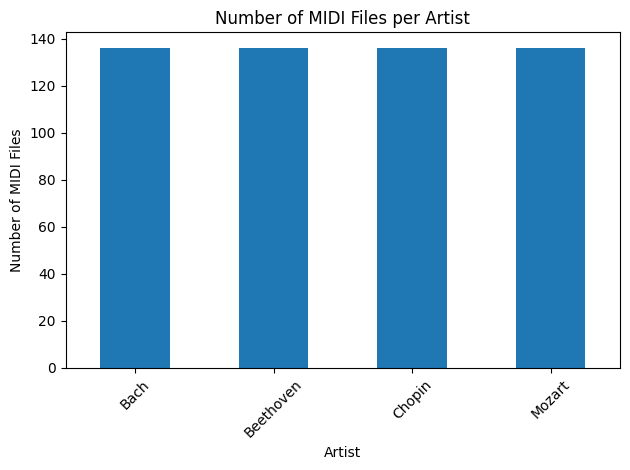

In [ ]:
artist_counts = midi_df["artist"].value_counts()

print(artist_counts)

artist_counts.plot(
    kind="bar",
    title="Number of MIDI Files per Artist"
)

plt.xlabel("Artist")
plt.ylabel("Number of MIDI Files")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
metadata_columns = [
    "file_name",
    "file_path",
    "relative_path",
    "parent_folder",
    "artist"
]

# The original notebook accidentally included relative_path and parent_folder as
# model features, which caused the median imputer to fail on text values.
feature_columns = [
    column
    for column in midi_df.select_dtypes(include=[np.number]).columns
    if column not in metadata_columns
]

X = midi_df[feature_columns].copy()
X = X.replace([np.inf, -np.inf], np.nan)
y = midi_df["artist"].copy()

print("Number of numeric features:", len(feature_columns))
print(feature_columns)

Number of numeric features: 42
['tempo', 'total_duration', 'number_of_tracks', 'melodic_track_count', 'drum_track_count', 'unique_instruments', 'number_of_notes', 'note_density', 'pitch_mean', 'pitch_std', 'pitch_min', 'pitch_max', 'pitch_range', 'velocity_mean', 'velocity_std', 'velocity_min', 'velocity_max', 'duration_mean', 'duration_std', 'duration_median', 'duration_min', 'duration_max', 'interval_mean', 'interval_std', 'interval_max', 'polyphony_rate', 'time_signature_numerator', 'time_signature_denominator', 'first_key_number', 'number_of_key_changes', 'pitch_class_0', 'pitch_class_1', 'pitch_class_2', 'pitch_class_3', 'pitch_class_4', 'pitch_class_5', 'pitch_class_6', 'pitch_class_7', 'pitch_class_8', 'pitch_class_9', 'pitch_class_10', 'pitch_class_11']


In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Artist classes:", label_encoder.classes_)

Artist classes: ['Bach' 'Beethoven' 'Chopin' 'Mozart']


In [ ]:
all_positions = np.arange(len(X))

development_positions, test_positions = train_test_split(
    all_positions,
    test_size=108,
    random_state=SEED,
    stratify=y_encoded
)

train_positions, validation_positions = train_test_split(
    development_positions,
    test_size=44,
    random_state=SEED,
    stratify=y_encoded[development_positions]
)

X_train = X.iloc[train_positions]
X_test = X.iloc[test_positions]

y_train = y_encoded[train_positions]
y_test = y_encoded[test_positions]

print("Training samples:", len(train_positions))
print("Validation samples:", len(validation_positions))
print("Testing samples:", len(test_positions))

Training samples: 392
Validation samples: 44
Testing samples: 108


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]),

    "Support Vector Machine": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "classifier",
            SVC(
                kernel="rbf",
                class_weight="balanced",
                probability=True,
                random_state=42
            )
        )
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=500,
                max_depth=None,
                min_samples_split=2,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ])
}

In [ ]:
model_results = []
trained_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    macro_precision = precision_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0
    )

    model_results.append({
        "model": model_name,
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1
    })

    trained_models[model_name] = model

    print("=" * 70)
    print(model_name)
    print(f"Accuracy:        {accuracy:.4f}")
    print(f"Macro Precision: {macro_precision:.4f}")
    print(f"Macro Recall:    {macro_recall:.4f}")
    print(f"Macro F1:        {macro_f1:.4f}")

    print(
        classification_report(
            y_test,
            predictions,
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )

baseline_results_df = (
    pd.DataFrame(model_results)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

baseline_results_df.to_csv(
    "baseline_model_results.csv",
    index=False
)

baseline_results_df

Logistic Regression
Accuracy:        0.7222
Macro Precision: 0.7212
Macro Recall:    0.7222
Macro F1:        0.7192
              precision    recall  f1-score   support

        Bach       0.84      0.78      0.81        27
   Beethoven       0.65      0.56      0.60        27
      Chopin       0.81      0.93      0.86        27
      Mozart       0.59      0.63      0.61        27

    accuracy                           0.72       108
   macro avg       0.72      0.72      0.72       108
weighted avg       0.72      0.72      0.72       108

Support Vector Machine
Accuracy:        0.8056
Macro Precision: 0.8134
Macro Recall:    0.8056
Macro F1:        0.8020
              precision    recall  f1-score   support

        Bach       0.88      0.78      0.82        27
   Beethoven       0.86      0.67      0.75        27
      Chopin       0.77      1.00      0.87        27
      Mozart       0.75      0.78      0.76        27

    accuracy                           0.81       108
   m

,model,accuracy,macro_precision,macro_recall,macro_f1
0,Random Forest,0.861111,0.866981,0.861111,0.858956
1,Support Vector Machine,0.805556,0.813393,0.805556,0.802033
2,Logistic Regression,0.722222,0.721208,0.722222,0.719226


In [ ]:
# Test-set predictions for the classical models to plot confusion matrices later.

classical_predictions = {}

for model_name, model in trained_models.items():
    preds = model.predict(X_test)
    classical_predictions[model_name] = {
        "y_true": label_encoder.inverse_transform(y_test),
        "y_pred": label_encoder.inverse_transform(preds)
    }

print("Saved predictions for:", list(classical_predictions.keys()))

Saved predictions for: ['Logistic Regression', 'Support Vector Machine', 'Random Forest']


## Thomas Geraci: Model Building and Model Training

## Final 20 FPS configuration and balanced 80/20 plan

This cell sets the final training conditions used for both deep-learning models. The final experiments use 20 FPS as a consistent piano-roll representation while limiting computational cost. I also set the segment length, batch size, maximum epochs, learning rate, early stopping, and training device. Keeping these settings consistent allows the CNN and CNN-LSTM to be compared under the same controlled conditions.

In [ ]:
#Final deep-learning configuration selected from the completed FPS comparison.
import hashlib

PIANO_ROLL_FPS = 20
SEGMENT_SECONDS = 10.0

#A larger batch is practical at 20 FPS and reduces the number of CPU steps.
BATCH_SIZE = int(os.environ.get("SCOREMATCH_BATCH_SIZE", "16"))

#Early stopping normally ends training before this maximum when validation
#performance stops improving.
MAX_EPOCHS = int(
    os.environ.get(
        "SCOREMATCH_EPOCHS",
        "3" if FAST_RUN else "15",
    )
)
EARLY_STOPPING_PATIENCE = 2 if FAST_RUN else 3

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0  #safest setting for Windows/Jupyter

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

ARTIFACT_DIR = (
    Path("scorematch_artifacts")
    / f"final_{FILES_PER_COMPOSER}_80_20_{PIANO_ROLL_FPS}fps"
)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)
print("Files per composer:", FILES_PER_COMPOSER)
print("Selected FPS:", PIANO_ROLL_FPS)
print("Segment duration:", SEGMENT_SECONDS, "seconds")
print("Maximum epochs:", MAX_EPOCHS)
print("Early-stopping patience:", EARLY_STOPPING_PATIENCE)
print("Batch size:", BATCH_SIZE)
print("Artifact directory:", ARTIFACT_DIR.resolve())

Device: cuda
Files per composer: 136
Selected FPS: 20
Segment duration: 10.0 seconds
Maximum epochs: 15
Early-stopping patience: 3
Batch size: 16
Artifact directory: /content/scorematch_artifacts/final_136_80_20_20fps


## Data Split

This cell reuses the shared balanced split created earlier in the notebook so the classical models, CNN, and CNN-LSTM are evaluated using the same files. Each composer contributes 98 training, 11 validation, and 27 testing files, for totals of 392 training, 44 validation, and 108 testing files. Preprocessing is fitted only on the training set to prevent data leakage, and a split manifest is saved for reproducibility.

In [ ]:
# -------------------------------------------------------------------------
# SHARED DATA SPLIT FOR DEEP-LEARNING MODELS
# -------------------------------------------------------------------------
# The train, validation, and test positions were created earlier and are
# reused here so the classical models, CNN, and CNN-LSTM are evaluated
# using the exact same files.
# -------------------------------------------------------------------------

# Verify the expected controlled split.
assert len(development_positions) == 436, (
    f"Expected 436 development files, found {len(development_positions)}."
)

assert len(train_positions) == 392, (
    f"Expected 392 training files, found {len(train_positions)}."
)

assert len(validation_positions) == 44, (
    f"Expected 44 validation files, found {len(validation_positions)}."
)

assert len(test_positions) == 108, (
    f"Expected 108 testing files, found {len(test_positions)}."
)


# Confirm that the three sets do not overlap.
assert set(train_positions).isdisjoint(validation_positions), (
    "Training and validation sets overlap."
)

assert set(train_positions).isdisjoint(test_positions), (
    "Training and test sets overlap."
)

assert set(validation_positions).isdisjoint(test_positions), (
    "Validation and test sets overlap."
)


# Confirm that every controlled sample belongs to exactly one split.
all_split_positions = np.concatenate([
    train_positions,
    validation_positions,
    test_positions
])

assert len(np.unique(all_split_positions)) == len(X), (
    "The shared split does not account for every controlled sample exactly once."
)


# -------------------------------------------------------------------------
# FEATURE PREPROCESSING
# -------------------------------------------------------------------------
# Fit preprocessing ONLY on the training subset to prevent data leakage.
# Validation and test data are transformed using statistics learned from
# the training data only.
# -------------------------------------------------------------------------

deep_feature_imputer = SimpleImputer(strategy="median")
deep_feature_scaler = StandardScaler()

train_numeric = deep_feature_imputer.fit_transform(
    X.iloc[train_positions]
)

deep_feature_scaler.fit(train_numeric)

all_numeric_imputed = deep_feature_imputer.transform(X)

all_engineered_features = deep_feature_scaler.transform(
    all_numeric_imputed
).astype(np.float32)


# -------------------------------------------------------------------------
# SPLIT MANIFEST
# -------------------------------------------------------------------------
# Save the exact shared split for reproducibility and final evaluation.
# -------------------------------------------------------------------------

split_manifest = midi_df[
    [
        "artist",
        "file_name",
        "file_path",
        "relative_path",
        "parent_folder",
    ]
].copy()

split_manifest["split"] = ""

split_manifest.loc[
    train_positions,
    "split"
] = "train"

split_manifest.loc[
    validation_positions,
    "split"
] = "validation"

split_manifest.loc[
    test_positions,
    "split"
] = "test"


# Save the manifest.
manifest_path = ARTIFACT_DIR / "dataset_split_manifest.csv"

split_manifest.to_csv(
    manifest_path,
    index=False
)


# -------------------------------------------------------------------------
# SPLIT SUMMARY
# -------------------------------------------------------------------------

split_summary = (
    split_manifest
    .groupby(["artist", "split"])
    .size()
    .rename("samples")
    .reset_index()
)


# Verify the expected per-composer distribution.
expected_split_counts = {
    "train": 98,
    "validation": 11,
    "test": 27,
}

for split_name, expected_count in expected_split_counts.items():

    observed = (
        split_summary[
            split_summary["split"] == split_name
        ]["samples"]
    )

    assert len(observed) == 4, (
        f"Expected all four composers in the {split_name} split."
    )

    assert (observed == expected_count).all(), (
        f"Unexpected number of files in the {split_name} split."
    )


# -------------------------------------------------------------------------
# FINAL VERIFICATION OUTPUT
# -------------------------------------------------------------------------

print("Shared data split verified successfully.")
print("Development files:", len(development_positions))
print("Training files:", len(train_positions))
print("Validation files:", len(validation_positions))
print("Testing files:", len(test_positions))
print("Engineered features:", all_engineered_features.shape[1])
print("Saved split manifest:", manifest_path)

display(split_summary)

Shared data split verified successfully.
Development files: 436
Training files: 392
Validation files: 44
Testing files: 108
Engineered features: 42
Saved split manifest: scorematch_artifacts/final_136_80_20_20fps/dataset_split_manifest.csv


,artist,split,samples
0,Bach,test,27
1,Bach,train,98
2,Bach,validation,11
3,Beethoven,test,27
4,Beethoven,train,98
5,Beethoven,validation,11
6,Chopin,test,27
7,Chopin,train,98
8,Chopin,validation,11
9,Mozart,test,27


## Precompute the selected 20 FPS piano rolls once

This cell converts each MIDI file into a fixed 10-second piano-roll segment at 20 FPS. A repeatable starting point is selected for every file, so the same musical section is used each time the notebook runs. The piano rolls are saved in a compact cache instead of reopening and converting every MIDI file during every epoch. This step is needed because the CNN and CNN-LSTM require numerical tensors rather than raw MIDI files, and precomputing the tensors greatly reduces training time in the Colab runtime.

In [ ]:
def stable_segment_start_seconds(
    file_path,
    midi_duration_seconds,
    segment_seconds,
    random_state=42,
):
    """Choose one deterministic segment start for each MIDI file."""
    maximum_start = max(
        0.0,
        float(midi_duration_seconds) - float(segment_seconds),
    )

    if maximum_start == 0.0:
        return 0.0

    digest = hashlib.sha256(
        f"{Path(file_path).as_posix()}|{random_state}".encode("utf-8")
    ).digest()

    fraction = int.from_bytes(
        digest[:8],
        byteorder="big",
        signed=False,
    ) / float(2**64 - 1)

    return fraction * maximum_start


def create_piano_roll_segment_uint8(
    file_path,
    frames_per_second=20,
    segment_seconds=10.0,
    random_state=42,
):
    """
    Convert one deterministic MIDI segment to [128, frames] uint8 velocity data.

    uint8 storage reduces the complete 544-file piano-roll cache to roughly
    14 MB at 20 FPS.
    """
    midi = pretty_midi.PrettyMIDI(str(file_path))

    target_frames = int(
        round(frames_per_second * segment_seconds)
    )

    start_seconds = stable_segment_start_seconds(
        file_path,
        midi.get_end_time(),
        segment_seconds,
        random_state,
    )

    sample_times = (
        start_seconds
        + np.arange(target_frames, dtype=np.float64)
        / float(frames_per_second)
    )

    piano_roll = midi.get_piano_roll(
        times=sample_times
    )

    if piano_roll.shape[1] < target_frames:
        piano_roll = np.pad(
            piano_roll,
            (
                (0, 0),
                (0, target_frames - piano_roll.shape[1]),
            ),
            mode="constant",
        )
    elif piano_roll.shape[1] > target_frames:
        piano_roll = piano_roll[:, :target_frames]

    return np.clip(
        np.rint(piano_roll),
        0,
        127,
    ).astype(np.uint8)


TARGET_FRAMES = int(
    round(PIANO_ROLL_FPS * SEGMENT_SECONDS)
)

PIANO_ROLL_CACHE_PATH = (
    ARTIFACT_DIR
    / f"piano_roll_cache_{PIANO_ROLL_FPS}fps_{TARGET_FRAMES}frames.npy"
)

expected_shape = (
    len(midi_df),
    128,
    TARGET_FRAMES,
)

use_existing_cache = False

if PIANO_ROLL_CACHE_PATH.exists():
    cached_shape = np.load(
        PIANO_ROLL_CACHE_PATH,
        mmap_mode="r",
    ).shape

    if cached_shape == expected_shape:
        use_existing_cache = True
        print("Using existing piano-roll cache:", PIANO_ROLL_CACHE_PATH)

if not use_existing_cache:
    print(
        f"Precomputing {len(midi_df)} piano rolls at "
        f"{PIANO_ROLL_FPS} FPS..."
    )

    piano_roll_array = np.empty(
        expected_shape,
        dtype=np.uint8,
    )

    started_at = time.time()

    for position, file_path in enumerate(midi_df["file_path"]):
        piano_roll_array[position] = (
            create_piano_roll_segment_uint8(
                file_path,
                frames_per_second=PIANO_ROLL_FPS,
                segment_seconds=SEGMENT_SECONDS,
                random_state=SEED,
            )
        )

        if (
            (position + 1) % 50 == 0
            or (position + 1) == len(midi_df)
        ):
            print(
                f"Prepared {position + 1}/{len(midi_df)} MIDI files."
            )

    np.save(
        PIANO_ROLL_CACHE_PATH,
        piano_roll_array,
    )

    elapsed_seconds = time.time() - started_at
    print(
        f"Saved piano-roll cache in "
        f"{elapsed_seconds / 60:.2f} minutes:"
    )
    print(PIANO_ROLL_CACHE_PATH)

# Memory mapping avoids duplicating the complete cache in RAM.
all_piano_rolls_uint8 = np.load(
    PIANO_ROLL_CACHE_PATH,
    mmap_mode="r",
)

print("Piano-roll cache shape:", all_piano_rolls_uint8.shape)
print("Piano-roll cache dtype:", all_piano_rolls_uint8.dtype)

Using existing piano-roll cache: scorematch_artifacts/final_136_80_20_20fps/piano_roll_cache_20fps_200frames.npy
Piano-roll cache shape: (544, 128, 200)
Piano-roll cache dtype: uint8


## Training Preparation

This cell prepares the cached piano rolls for training. It applies small changes such as pitch shifts, short time shifts, masking, and slight velocity variation only to the training examples. These changes create realistic variation without changing the composer label. The custom dataset then combines each piano roll with the extracted numerical MIDI features, and the data loaders send the files to the model in batches. Class weights are also calculated for the loss function. This is needed to reduce overfitting, organize the data correctly for PyTorch, and make sure both models receive the same type of input.

,composer,training_files,class_weight
0,Bach,98,1.0
1,Beethoven,98,1.0
2,Chopin,98,1.0
3,Mozart,98,1.0


Sample piano-roll tensor: (1, 128, 200)
Expected frames: 200
Feature tensor: (42,)
Label: 2 -> Chopin
Source MIDI: /content/scorematch_data/archive/Chopin/Nocturne op48 n1.mid


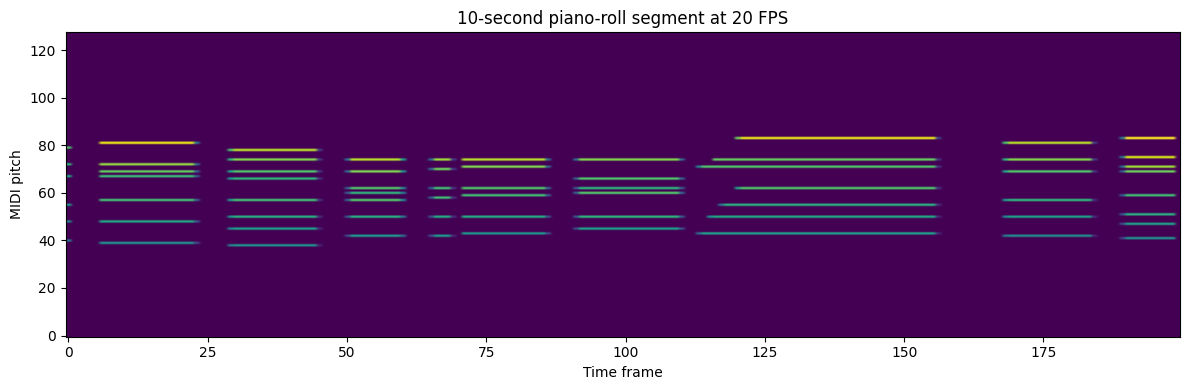

In [ ]:
def augment_piano_roll(piano_roll):
    """Light piano-roll augmentation applied only to training samples."""
    augmented = piano_roll.copy()

    #Small pitch transposition.
    if random.random() < 0.50:
        pitch_shift = random.choice([-2, -1, 1, 2])
        augmented = np.roll(
            augmented,
            pitch_shift,
            axis=0,
        )

        if pitch_shift > 0:
            augmented[:pitch_shift, :] = 0.0
        else:
            augmented[pitch_shift:, :] = 0.0

    #Shift by at most 0.25 seconds.
    if random.random() < 0.50:
        maximum_shift = max(
            1,
            int(round(0.25 * PIANO_ROLL_FPS)),
        )
        time_shift = random.randint(
            -maximum_shift,
            maximum_shift,
        )

        augmented = np.roll(
            augmented,
            time_shift,
            axis=1,
        )

        if time_shift > 0:
            augmented[:, :time_shift] = 0.0
        elif time_shift < 0:
            augmented[:, time_shift:] = 0.0

    #Mask between 0.10 and 0.40 seconds.
    if random.random() < 0.40:
        minimum_mask = max(
            1,
            int(round(0.10 * PIANO_ROLL_FPS)),
        )
        maximum_mask = max(
            minimum_mask,
            int(round(0.40 * PIANO_ROLL_FPS)),
        )

        mask_width = random.randint(
            minimum_mask,
            maximum_mask,
        )
        mask_width = min(
            mask_width,
            augmented.shape[1],
        )

        mask_start = random.randint(
            0,
            augmented.shape[1] - mask_width,
        )

        augmented[
            :,
            mask_start:mask_start + mask_width,
        ] = 0.0

    augmented *= random.uniform(0.90, 1.10)

    if random.random() < 0.30:
        augmented += np.random.normal(
            0.0,
            0.01,
            size=augmented.shape,
        ).astype(np.float32)

    return np.clip(
        augmented,
        0.0,
        1.0,
    ).astype(np.float32)


class PrecomputedPianoRollDataset(Dataset):
    """Return a cached piano roll, features, label, and source path."""

    def __init__(
        self,
        dataframe,
        positions,
        piano_rolls_uint8,
        engineered_features,
        encoded_labels,
        training=False,
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.positions = np.asarray(positions, dtype=int)
        self.piano_rolls_uint8 = piano_rolls_uint8
        self.engineered_features = engineered_features
        self.encoded_labels = np.asarray(
            encoded_labels,
            dtype=np.int64,
        )
        self.training = training

    def __len__(self):
        return len(self.positions)

    def __getitem__(self, item):
        position = int(self.positions[item])

        piano_roll = (
            np.asarray(
                self.piano_rolls_uint8[position],
                dtype=np.float32,
            )
            / 127.0
        )

        if self.training:
            piano_roll = augment_piano_roll(piano_roll)

        piano_roll_tensor = torch.from_numpy(
            piano_roll
        ).unsqueeze(0)

        feature_tensor = torch.from_numpy(
            self.engineered_features[position]
        )

        label_tensor = torch.tensor(
            self.encoded_labels[position],
            dtype=torch.long,
        )

        file_path = self.dataframe.iloc[
            position
        ]["file_path"]

        return (
            piano_roll_tensor,
            feature_tensor,
            label_tensor,
            file_path,
        )


def reset_experiment_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_data_loaders():
    train_dataset = PrecomputedPianoRollDataset(
        midi_df,
        train_positions,
        all_piano_rolls_uint8,
        all_engineered_features,
        y_encoded,
        training=True,
    )

    validation_dataset = PrecomputedPianoRollDataset(
        midi_df,
        validation_positions,
        all_piano_rolls_uint8,
        all_engineered_features,
        y_encoded,
        training=False,
    )

    test_dataset = PrecomputedPianoRollDataset(
        midi_df,
        test_positions,
        all_piano_rolls_uint8,
        all_engineered_features,
        y_encoded,
        training=False,
    )

    loader_generator = torch.Generator()
    loader_generator.manual_seed(SEED)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        generator=loader_generator,
    )

    validation_loader = DataLoader(
        validation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
    )

    return (
        train_dataset,
        validation_dataset,
        test_dataset,
        train_loader,
        validation_loader,
        test_loader,
    )


(
    train_dataset,
    validation_dataset,
    test_dataset,
    train_loader,
    validation_loader,
    test_loader,
) = make_data_loaders()

#Class-weighted SoftMax cross-entropy.
training_label_counts = np.bincount(
    y_encoded[train_positions],
    minlength=len(label_encoder.classes_),
)

class_weights = len(train_positions) / (
    len(label_encoder.classes_)
    * training_label_counts
)

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE,
)

class_weight_table = pd.DataFrame({
    "composer": label_encoder.classes_,
    "training_files": training_label_counts,
    "class_weight": class_weights,
})

display(class_weight_table)

sample_roll, sample_features, sample_label, sample_path = (
    validation_dataset[0]
)

print("Sample piano-roll tensor:", tuple(sample_roll.shape))
print("Expected frames:", TARGET_FRAMES)
print("Feature tensor:", tuple(sample_features.shape))
print(
    "Label:",
    int(sample_label),
    "->",
    label_encoder.inverse_transform(
        [int(sample_label)]
    )[0],
)
print("Source MIDI:", sample_path)

plt.figure(figsize=(12, 4))
plt.imshow(
    sample_roll.squeeze(0).numpy(),
    aspect="auto",
    origin="lower",
)
plt.title(
    f"{SEGMENT_SECONDS:g}-second piano-roll segment at "
    f"{PIANO_ROLL_FPS} FPS"
)
plt.xlabel("Time frame")
plt.ylabel("MIDI pitch")
plt.tight_layout()
plt.show()

## CNN and CNN-LSTM

This cell builds the two models assigned to me. The shared feature branch processes the extracted information such as tempo, pitch, duration, rhythm, and velocity. The CNN learns visual patterns from the piano roll, while the CNN-LSTM uses convolutional layers for local patterns and an LSTM for the order of those patterns over time. Each model combines the piano-roll representation with the extracted features before predicting Bach, Beethoven, Chopin, or Mozart. This code is needed to meet my requirement of building both a CNN and a CNN-LSTM composer classifier in PyTorch.

In [ ]:
class FeatureBranch(nn.Module):
    def __init__(
        self,
        input_features,
        output_features=64,
        dropout=0.30,
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_features, 128),
            nn.ReLU(),
            nn.LayerNorm(128),
            nn.Dropout(dropout),
            nn.Linear(128, output_features),
            nn.ReLU(),
        )

    def forward(self, engineered_features):
        return self.network(engineered_features)


class ScoreMatchCNN(nn.Module):
    """CNN piano-roll encoder fused with extracted MIDI features."""

    def __init__(
        self,
        engineered_feature_count,
        number_of_classes,
        dropout=0.40,
    ):
        super().__init__()

        self.piano_roll_encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.AdaptiveAvgPool2d((4, 4)),
        )

        self.feature_branch = FeatureBranch(
            engineered_feature_count,
            output_features=64,
            dropout=0.30,
        )

        self.classifier = nn.Sequential(
            nn.Linear((64 * 4 * 4) + 64, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, number_of_classes),
        )

    def forward(
        self,
        piano_roll,
        engineered_features,
    ):
        roll_embedding = self.piano_roll_encoder(
            piano_roll
        )
        roll_embedding = torch.flatten(
            roll_embedding,
            start_dim=1,
        )

        feature_embedding = self.feature_branch(
            engineered_features
        )

        combined = torch.cat(
            [roll_embedding, feature_embedding],
            dim=1,
        )

        return self.classifier(combined)


class ScoreMatchCNNLSTM(nn.Module):
    """CNN extracts local patterns and an LSTM models temporal order."""

    def __init__(
        self,
        engineered_feature_count,
        number_of_classes,
        lstm_hidden_size=64,
        dropout=0.40,
    ):
        super().__init__()

        self.convolutional_encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )

        self.temporal_model = nn.LSTM(
            input_size=64,
            hidden_size=lstm_hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )

        self.feature_branch = FeatureBranch(
            engineered_feature_count,
            output_features=64,
            dropout=0.30,
        )

        self.classifier = nn.Sequential(
            nn.Linear(
                (lstm_hidden_size * 2) + 64,
                128,
            ),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, number_of_classes),
        )

    def forward(
        self,
        piano_roll,
        engineered_features,
    ):
        encoded = self.convolutional_encoder(
            piano_roll
        )

        # Average over pitch and retain the reduced temporal sequence.
        sequence = encoded.mean(dim=2).transpose(1, 2)

        _, (hidden_state, _) = self.temporal_model(
            sequence
        )

        forward_hidden = hidden_state[-2]
        backward_hidden = hidden_state[-1]

        temporal_embedding = torch.cat(
            [forward_hidden, backward_hidden],
            dim=1,
        )

        feature_embedding = self.feature_branch(
            engineered_features
        )

        combined = torch.cat(
            [temporal_embedding, feature_embedding],
            dim=1,
        )

        return self.classifier(combined)


def count_trainable_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


number_of_classes = len(label_encoder.classes_)
engineered_feature_count = len(feature_columns)

model_builders = {
    "CNN": lambda: ScoreMatchCNN(
        engineered_feature_count,
        number_of_classes,
    ),
    "CNN-LSTM": lambda: ScoreMatchCNNLSTM(
        engineered_feature_count,
        number_of_classes,
    ),
}

for model_name, builder in model_builders.items():
    preview_model = builder()
    print(
        f"{model_name}: "
        f"{count_trainable_parameters(preview_model):,} "
        "trainable parameters"
    )

CNN: 317,348 trainable parameters
CNN-LSTM: 129,316 trainable parameters


## Train both required models with validation and early stopping

This cell defines how the models are trained and validated. During each training epoch, the model makes predictions, calculates class-weighted cross-entropy loss, updates its weights with AdamW, and uses gradient clipping for stability. After each epoch, the model is checked on the validation set using loss, accuracy, and macro-F1. Early stopping keeps the best version of the model and ends training when validation performance stops improving. This is needed to train the models correctly, limit overfitting, and avoid wasting time on extra epochs that are no longer helping.

In [ ]:
def run_training_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for (
        piano_rolls,
        engineered_features,
        labels,
        _,
    ) in data_loader:
        piano_rolls = piano_rolls.to(
            DEVICE,
            non_blocking=True,
        )
        engineered_features = engineered_features.to(
            DEVICE,
            non_blocking=True,
        )
        labels = labels.to(
            DEVICE,
            non_blocking=True,
        )

        optimizer.zero_grad(set_to_none=True)

        logits = model(
            piano_rolls,
            engineered_features,
        )

        loss = criterion(logits, labels)
        loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0,
        )

        optimizer.step()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        correct += (
            logits.argmax(dim=1) == labels
        ).sum().item()
        total += batch_size

    return {
        "loss": running_loss / max(total, 1),
        "accuracy": correct / max(total, 1),
    }


@torch.no_grad()
def evaluate_model(
    model,
    data_loader,
    criterion,
    return_predictions=False,
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_predictions = []
    all_paths = []

    for (
        piano_rolls,
        engineered_features,
        labels,
        file_paths,
    ) in data_loader:
        piano_rolls = piano_rolls.to(
            DEVICE,
            non_blocking=True,
        )
        engineered_features = engineered_features.to(
            DEVICE,
            non_blocking=True,
        )
        labels = labels.to(
            DEVICE,
            non_blocking=True,
        )

        logits = model(
            piano_rolls,
            engineered_features,
        )

        loss = criterion(logits, labels)
        predictions = logits.argmax(dim=1)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        correct += (
            predictions == labels
        ).sum().item()
        total += batch_size

        all_labels.extend(
            labels.cpu().numpy().tolist()
        )
        all_predictions.extend(
            predictions.cpu().numpy().tolist()
        )

        if return_predictions:
            all_paths.extend(list(file_paths))

    labels_array = np.asarray(all_labels)
    predictions_array = np.asarray(all_predictions)

    metrics = {
        "loss": running_loss / max(total, 1),
        "accuracy": correct / max(total, 1),
        "macro_f1": f1_score(
            labels_array,
            predictions_array,
            average="macro",
            zero_division=0,
        ),
    }

    if return_predictions:
        metrics["labels"] = labels_array
        metrics["predictions"] = predictions_array
        metrics["file_paths"] = all_paths

    return metrics


def train_scorematch_model(
    model_name,
    model,
):
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss(
        weight=class_weights_tensor
    )

    optimizer = optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=1,
        min_lr=1e-6,
    )

    history = {
        "epoch": [],
        "train_loss": [],
        "train_accuracy": [],
        "validation_loss": [],
        "validation_accuracy": [],
        "validation_macro_f1": [],
        "learning_rate": [],
    }

    best_state = copy.deepcopy(
        model.state_dict()
    )
    best_validation_f1 = -np.inf
    best_validation_loss = np.inf
    epochs_without_improvement = 0

    started_at = time.time()

    for epoch in range(1, MAX_EPOCHS + 1):
        training_metrics = run_training_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
        )

        validation_metrics = evaluate_model(
            model,
            validation_loader,
            criterion,
            return_predictions=False,
        )

        scheduler.step(
            validation_metrics["macro_f1"]
        )

        current_learning_rate = (
            optimizer.param_groups[0]["lr"]
        )

        history["epoch"].append(epoch)
        history["train_loss"].append(
            training_metrics["loss"]
        )
        history["train_accuracy"].append(
            training_metrics["accuracy"]
        )
        history["validation_loss"].append(
            validation_metrics["loss"]
        )
        history["validation_accuracy"].append(
            validation_metrics["accuracy"]
        )
        history["validation_macro_f1"].append(
            validation_metrics["macro_f1"]
        )
        history["learning_rate"].append(
            current_learning_rate
        )

        print(
            f"{model_name} | Epoch {epoch:02d}/{MAX_EPOCHS} | "
            f"train loss {training_metrics['loss']:.4f} | "
            f"train acc {training_metrics['accuracy']:.4f} | "
            f"val loss {validation_metrics['loss']:.4f} | "
            f"val acc {validation_metrics['accuracy']:.4f} | "
            f"val F1 {validation_metrics['macro_f1']:.4f}"
        )

        improved = (
            validation_metrics["macro_f1"]
            > best_validation_f1 + 1e-6
        )

        tied_f1_lower_loss = (
            abs(
                validation_metrics["macro_f1"]
                - best_validation_f1
            ) <= 1e-6
            and validation_metrics["loss"]
            < best_validation_loss
        )

        if improved or tied_f1_lower_loss:
            best_validation_f1 = (
                validation_metrics["macro_f1"]
            )
            best_validation_loss = (
                validation_metrics["loss"]
            )
            best_state = copy.deepcopy(
                model.state_dict()
            )
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= EARLY_STOPPING_PATIENCE
        ):
            print(
                f"Early stopping after epoch {epoch}. "
                f"Best validation macro-F1: "
                f"{best_validation_f1:.4f}"
            )
            break

    elapsed_seconds = time.time() - started_at

    model.load_state_dict(best_state)

    safe_model_name = (
        model_name.lower().replace("-", "_")
    )

    checkpoint_path = (
        ARTIFACT_DIR
        / f"scorematch_{safe_model_name}_{PIANO_ROLL_FPS}fps.pt"
    )

    torch.save(
        {
            "model_name": model_name,
            "fps": PIANO_ROLL_FPS,
            "segment_seconds": SEGMENT_SECONDS,
            "model_state_dict": model.state_dict(),
            "feature_count": engineered_feature_count,
            "class_names": label_encoder.classes_.tolist(),
            "best_validation_macro_f1": float(
                best_validation_f1
            ),
        },
        checkpoint_path,
    )

    history_frame = pd.DataFrame(history)

    history_path = (
        ARTIFACT_DIR
        / f"{safe_model_name}_training_history.csv"
    )
    history_frame.to_csv(
        history_path,
        index=False,
    )

    print(
        f"{model_name} completed in "
        f"{elapsed_seconds / 60:.2f} minutes."
    )
    print("Saved checkpoint:", checkpoint_path)
    print("Saved history:", history_path)

    return (
        model,
        history_frame,
        checkpoint_path,
        elapsed_seconds,
        best_validation_f1,
    )

## CNN and CNN-LSTM Training

This cell actually starts the training process for the CNN and CNN-LSTM. I reset the random seed before each model so the comparison is as consistent as possible, then train both models using the same 20 FPS data and the same training settings. The trained models, histories, checkpoint paths, training times, and best validation scores are stored for the next steps. This is needed because the previous cells only defined the process; this cell produces the two trained models required for my part of the project.

In [ ]:
trained_models = {}
training_histories = {}
checkpoint_paths = {}
training_metadata = {}

for model_name, builder in model_builders.items():
    reset_experiment_seed(SEED)

    print("\n" + "=" * 80)
    print(
        f"Training {model_name} at "
        f"{PIANO_ROLL_FPS} FPS"
    )
    print("=" * 80)

    (
        trained_model,
        history_frame,
        checkpoint_path,
        elapsed_seconds,
        best_validation_f1,
    ) = train_scorematch_model(
        model_name,
        builder(),
    )

    trained_models[model_name] = trained_model
    training_histories[model_name] = history_frame
    checkpoint_paths[model_name] = checkpoint_path
    training_metadata[model_name] = {
        "training_seconds": elapsed_seconds,
        "best_validation_macro_f1": best_validation_f1,
    }


Training CNN at 20 FPS
CNN | Epoch 01/15 | train loss 1.3894 | train acc 0.3189 | val loss 1.2696 | val acc 0.3636 | val F1 0.2769
CNN | Epoch 02/15 | train loss 1.0414 | train acc 0.5459 | val loss 0.8971 | val acc 0.6818 | val F1 0.6770
CNN | Epoch 03/15 | train loss 0.7414 | train acc 0.6913 | val loss 0.7168 | val acc 0.6591 | val F1 0.6511
CNN | Epoch 04/15 | train loss 0.6386 | train acc 0.7755 | val loss 0.6129 | val acc 0.7500 | val F1 0.7458
CNN | Epoch 05/15 | train loss 0.5362 | train acc 0.7857 | val loss 0.6502 | val acc 0.7273 | val F1 0.7296
CNN | Epoch 06/15 | train loss 0.5527 | train acc 0.7500 | val loss 0.6550 | val acc 0.6818 | val F1 0.6785
CNN | Epoch 07/15 | train loss 0.4106 | train acc 0.8469 | val loss 0.5947 | val acc 0.7727 | val F1 0.7727
CNN | Epoch 08/15 | train loss 0.4018 | train acc 0.8520 | val loss 0.6472 | val acc 0.7273 | val F1 0.7221
CNN | Epoch 09/15 | train loss 0.3519 | train acc 0.8724 | val loss 0.5528 | val acc 0.7727 | val F1 0.7733
CNN 

## Save the required curves, test accuracy results, and evaluation handoff

This cell creates and saves the loss and accuracy curves for both models. Each graph compares training performance with validation performance across the completed epochs. I can use these curves to see whether the model is learning, whether the results level off, and whether overfitting begins. This is needed because my assigned responsibilities include saving the training history, loss curves, and accuracy results for the final presentation.

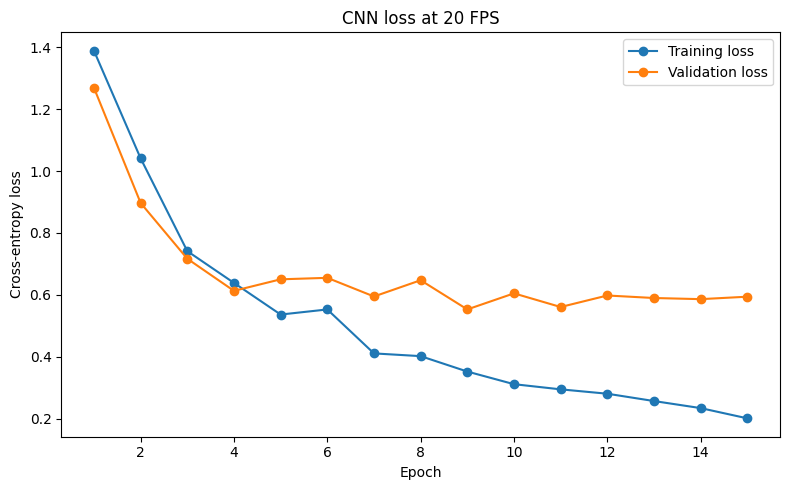

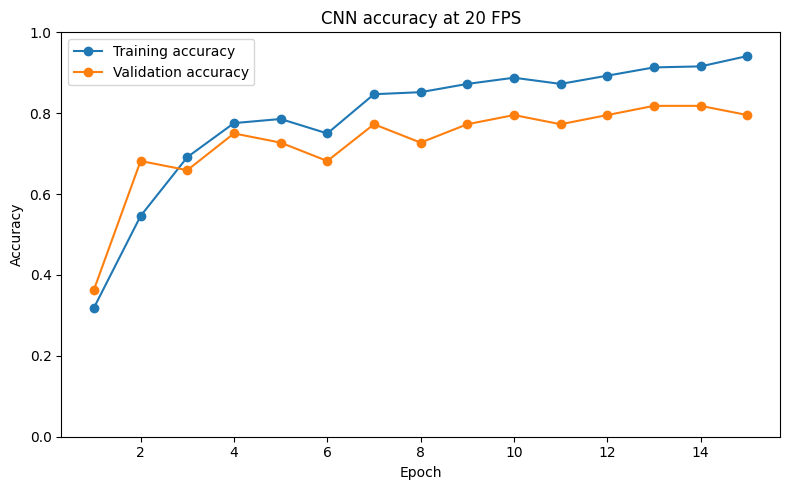

Saved: scorematch_artifacts/final_136_80_20_20fps/cnn_loss_curve.png
Saved: scorematch_artifacts/final_136_80_20_20fps/cnn_accuracy_curve.png


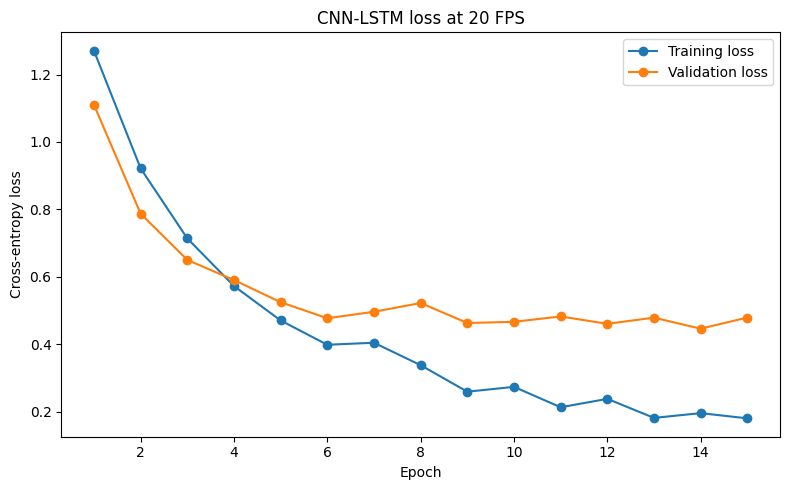

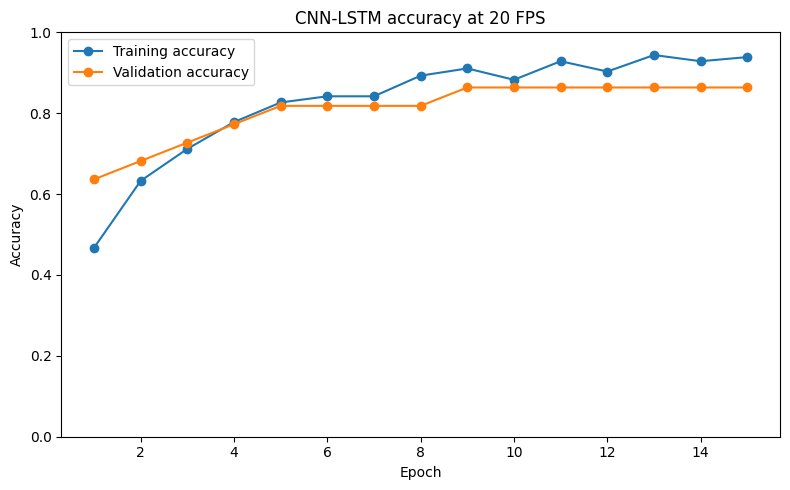

Saved: scorematch_artifacts/final_136_80_20_20fps/cnn_lstm_loss_curve.png
Saved: scorematch_artifacts/final_136_80_20_20fps/cnn_lstm_accuracy_curve.png


In [ ]:
for model_name, history_frame in training_histories.items():
    safe_model_name = (
        model_name.lower().replace("-", "_")
    )

    #Loss curve
    plt.figure(figsize=(8, 5))
    plt.plot(
        history_frame["epoch"],
        history_frame["train_loss"],
        marker="o",
        label="Training loss",
    )
    plt.plot(
        history_frame["epoch"],
        history_frame["validation_loss"],
        marker="o",
        label="Validation loss",
    )
    plt.title(
        f"{model_name} loss at "
        f"{PIANO_ROLL_FPS} FPS"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Cross-entropy loss")
    plt.legend()
    plt.tight_layout()

    loss_curve_path = (
        ARTIFACT_DIR
        / f"{safe_model_name}_loss_curve.png"
    )
    plt.savefig(
        loss_curve_path,
        dpi=150,
    )
    plt.show()

    #Accuracy curve
    plt.figure(figsize=(8, 5))
    plt.plot(
        history_frame["epoch"],
        history_frame["train_accuracy"],
        marker="o",
        label="Training accuracy",
    )
    plt.plot(
        history_frame["epoch"],
        history_frame["validation_accuracy"],
        marker="o",
        label="Validation accuracy",
    )
    plt.title(
        f"{model_name} accuracy at "
        f"{PIANO_ROLL_FPS} FPS"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.ylim(0.0, 1.0)
    plt.legend()
    plt.tight_layout()

    accuracy_curve_path = (
        ARTIFACT_DIR
        / f"{safe_model_name}_accuracy_curve.png"
    )
    plt.savefig(
        accuracy_curve_path,
        dpi=150,
    )
    plt.show()

    print("Saved:", loss_curve_path)
    print("Saved:", accuracy_curve_path)

## Final Test-Set Evaluation and Prediction Export

This cell performs the final evaluation on the untouched 20% test set. It calculates test accuracy, macro precision, macro recall, and macro-F1 for the CNN and CNN-LSTM, then saves the results and individual predictions. Macro averages give each composer equal importance when the scores are calculated. The prediction file can be used by Cameron for confusion matrices and composer-confusion analysis. This is needed to provide the final performance results from my trained models without using the test set to influence training.

In [ ]:
criterion_for_testing = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

model_results = []
prediction_frames = []

for model_name, model in trained_models.items():
    test_metrics = evaluate_model(
        model,
        test_loader,
        criterion_for_testing,
        return_predictions=True,
    )

    macro_precision = precision_score(
        test_metrics["labels"],
        test_metrics["predictions"],
        average="macro",
        zero_division=0,
    )

    macro_recall = recall_score(
        test_metrics["labels"],
        test_metrics["predictions"],
        average="macro",
        zero_division=0,
    )

    macro_f1 = f1_score(
        test_metrics["labels"],
        test_metrics["predictions"],
        average="macro",
        zero_division=0,
    )

    model_results.append({
        "model": model_name,
        "fps": PIANO_ROLL_FPS,
        "segment_seconds": SEGMENT_SECONDS,
        "training_files": len(train_positions),
        "validation_files": len(validation_positions),
        "testing_files": len(test_positions),
        "epochs_completed": len(
            training_histories[model_name]
        ),
        "test_loss": test_metrics["loss"],
        "test_accuracy": test_metrics["accuracy"],
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "best_validation_macro_f1": (
            training_metadata[model_name][
                "best_validation_macro_f1"
            ]
        ),
        "training_seconds": (
            training_metadata[model_name][
                "training_seconds"
            ]
        ),
        "checkpoint": str(
            checkpoint_paths[model_name]
        ),
    })

    prediction_frames.append(
        pd.DataFrame({
            "model": model_name,
            "fps": PIANO_ROLL_FPS,
            "file_path": test_metrics[
                "file_paths"
            ],
            "actual_composer": (
                label_encoder.inverse_transform(
                    test_metrics["labels"]
                )
            ),
            "predicted_composer": (
                label_encoder.inverse_transform(
                    test_metrics["predictions"]
                )
            ),
        })
    )

    print("=" * 70)
    print(
        f"{model_name} at "
        f"{PIANO_ROLL_FPS} FPS"
    )
    print(
        f"Test accuracy: "
        f"{test_metrics['accuracy']:.4f}"
    )
    print(f"Macro-F1: {macro_f1:.4f}")


final_results_df = pd.DataFrame(
    model_results
).sort_values(
    ["test_accuracy", "macro_f1"],
    ascending=False,
).reset_index(drop=True)

results_path = (
    ARTIFACT_DIR
    / "final_20fps_model_results.csv"
)
final_results_df.to_csv(
    results_path,
    index=False,
)

test_predictions_df = pd.concat(
    prediction_frames,
    ignore_index=True,
)

test_predictions_path = (
    ARTIFACT_DIR
    / "test_predictions_for_evaluation.csv"
)
test_predictions_df.to_csv(
    test_predictions_path,
    index=False,
)

print("\nBest final model:")
print(
    final_results_df.iloc[0][
        [
            "model",
            "fps",
            "test_accuracy",
            "macro_f1",
            "epochs_completed",
            "training_seconds",
        ]
    ]
)

print("\nSaved final results:", results_path)
print(
    "Saved predictions for Cameron's evaluation:",
    test_predictions_path,
)

display(final_results_df)

CNN at 20 FPS
Test accuracy: 0.7315
Macro-F1: 0.7273
CNN-LSTM at 20 FPS
Test accuracy: 0.7685
Macro-F1: 0.7615

Best final model:
model               CNN-LSTM
fps                       20
test_accuracy       0.768519
macro_f1            0.761501
epochs_completed          15
training_seconds    15.65198
Name: 0, dtype: object

Saved final results: scorematch_artifacts/final_136_80_20_20fps/final_20fps_model_results.csv
Saved predictions for Cameron's evaluation: scorematch_artifacts/final_136_80_20_20fps/test_predictions_for_evaluation.csv


,model,fps,segment_seconds,training_files,validation_files,testing_files,epochs_completed,test_loss,test_accuracy,macro_precision,macro_recall,macro_f1,best_validation_macro_f1,training_seconds,checkpoint
0,CNN-LSTM,20,10.0,392,44,108,15,0.567133,0.768519,0.772559,0.768519,0.761501,0.864456,15.65198,scorematch_artifacts/final_136_80_20_20fps/sco...
1,CNN,20,10.0,392,44,108,15,0.669054,0.731481,0.750025,0.731481,0.727298,0.820367,13.52426,scorematch_artifacts/final_136_80_20_20fps/sco...


## Cameron Aljilani: Model Evaluation and Performance Analysis

Evaluation of the CNN and CNN-LSTM test predictions.  
I am going to look at the overall accuracy and macro-F1, per-composer scores, confusion matrices, and how the deep models compare with the earlier Random Forest / SVM / Logistic Regression baselines.

### 1. Load Test Predictions

Load the prediction CSV that Thomas saved after training.  
Check that both models are present and lock the composer order for the rest of the evaluation.

In [ ]:
# Load the test-set predictions that Thomas exported for evaluation.
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_recall_fscore_support
)

# Path to the prediction file created in the final deep-learning cell
PRED_PATH = Path(
    "scorematch_artifacts/final_136_80_20_20fps/"
    "test_predictions_for_evaluation.csv"
)

# Load the predictions
pred_df = pd.read_csv(PRED_PATH)
print("Loaded prediction file shape:", pred_df.shape)
print("Columns:", list(pred_df.columns))
print("\nModels present:", pred_df["model"].unique().tolist())
print("Composers:", sorted(pred_df["actual_composer"].unique().tolist()))

# Confirm we have both models
assert set(pred_df["model"].unique()) >= {"CNN", "CNN-LSTM"}, \
    "Expected both CNN and CNN-LSTM predictions"

# Composer order used throughout the evaluation (alphabetical for consistency)
COMPOSERS = ["Bach", "Beethoven", "Chopin", "Mozart"]

Loaded prediction file shape: (216, 5)
Columns: ['model', 'fps', 'file_path', 'actual_composer', 'predicted_composer']

Models present: ['CNN', 'CNN-LSTM']
Composers: ['Bach', 'Beethoven', 'Chopin', 'Mozart']


### 2. Overall and Per-Composer Metrics

Accuracy, macro precision/recall/F1, and the full classification report for both models.  
Macro averages are used so each composer is weighted equally.

In [ ]:
# Compute accuracy, macro-averaged precision / recall / F1, and full classification reports for each deep model.

def evaluate_one_model(df, model_name, composers):
    """
    Return a dictionary of metrics and the sklearn classification report
    for a single model.
    """
    subset = df[df["model"] == model_name].copy()
    y_true = subset["actual_composer"]
    y_pred = subset["predicted_composer"]

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=composers, average="macro", zero_division=0
    )

    report = classification_report(
        y_true, y_pred, labels=composers, digits=4, zero_division=0
    )

    return {
        "model": model_name,
        "accuracy": acc,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
        "report": report,
        "y_true": y_true,
        "y_pred": y_pred,
    }


# Evaluate both models
cnn_metrics = evaluate_one_model(pred_df, "CNN", COMPOSERS)
cnn_lstm_metrics = evaluate_one_model(pred_df, "CNN-LSTM", COMPOSERS)

print("=" * 70)
print("CNN Test Results")
print("=" * 70)
print(f"Accuracy      : {cnn_metrics['accuracy']:.4f}")
print(f"Macro Precision: {cnn_metrics['macro_precision']:.4f}")
print(f"Macro Recall   : {cnn_metrics['macro_recall']:.4f}")
print(f"Macro F1       : {cnn_metrics['macro_f1']:.4f}")
print("\nClassification Report:")
print(cnn_metrics["report"])

print("=" * 70)
print("CNN-LSTM Test Results")
print("=" * 70)
print(f"Accuracy      : {cnn_lstm_metrics['accuracy']:.4f}")
print(f"Macro Precision: {cnn_lstm_metrics['macro_precision']:.4f}")
print(f"Macro Recall   : {cnn_lstm_metrics['macro_recall']:.4f}")
print(f"Macro F1       : {cnn_lstm_metrics['macro_f1']:.4f}")
print("\nClassification Report:")
print(cnn_lstm_metrics["report"])

CNN Test Results
Accuracy      : 0.7315
Macro Precision: 0.7500
Macro Recall   : 0.7315
Macro F1       : 0.7273

Classification Report:
              precision    recall  f1-score   support

        Bach     0.9091    0.7407    0.8163        27
   Beethoven     0.7222    0.4815    0.5778        27
      Chopin     0.7742    0.8889    0.8276        27
      Mozart     0.5946    0.8148    0.6875        27

    accuracy                         0.7315       108
   macro avg     0.7500    0.7315    0.7273       108
weighted avg     0.7500    0.7315    0.7273       108

CNN-LSTM Test Results
Accuracy      : 0.7685
Macro Precision: 0.7726
Macro Recall   : 0.7685
Macro F1       : 0.7615

Classification Report:
              precision    recall  f1-score   support

        Bach     0.8519    0.8519    0.8519        27
   Beethoven     0.7778    0.5185    0.6222        27
      Chopin     0.7273    0.8889    0.8000        27
      Mozart     0.7333    0.8148    0.7719        27

    accuracy    

### Metrics Takeaway

On the 10-second, 20 FPS inputs, the CNN achieved 0.7315 test accuracy and 0.7273 macro-F1, while the CNN-LSTM reached 0.7685 accuracy and 0.7615 macro-F1. The CNN-LSTM therefore performed better at the 10-second setting. Beethoven was the most difficult composer for both models, while Bach and Chopin generally produced the strongest class-level results.

### 3. Confusion Matrices

Raw count and row-normalized confusion matrices for both models.  
The normalized version shows the percentage of each composer that was predicted as each class.  
Figures are saved to the evaluation folder.

Saved: scorematch_artifacts/final_136_80_20_20fps/evaluation/cnn_confusion_matrices.png


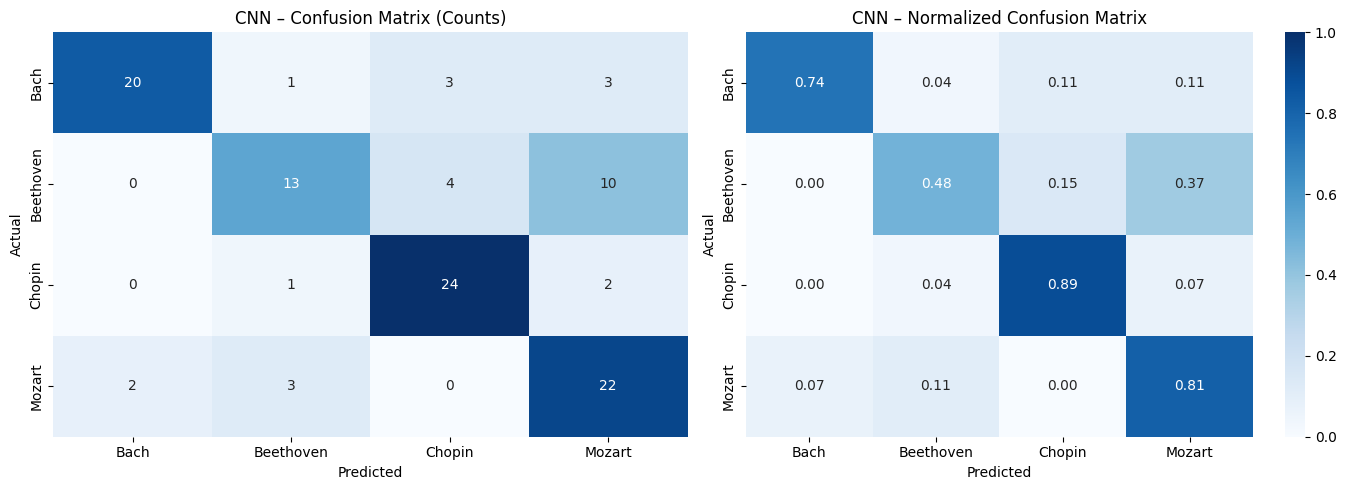

Saved: scorematch_artifacts/final_136_80_20_20fps/evaluation/cnn_lstm_confusion_matrices.png


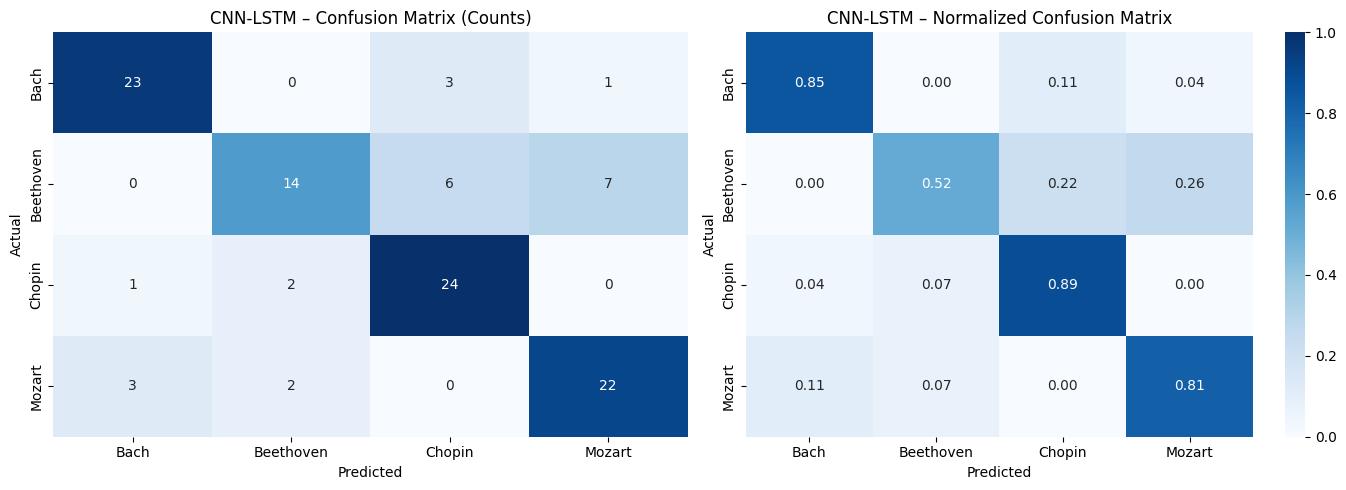

Saved: scorematch_artifacts/final_136_80_20_20fps/evaluation/random forest_confusion_matrices.png


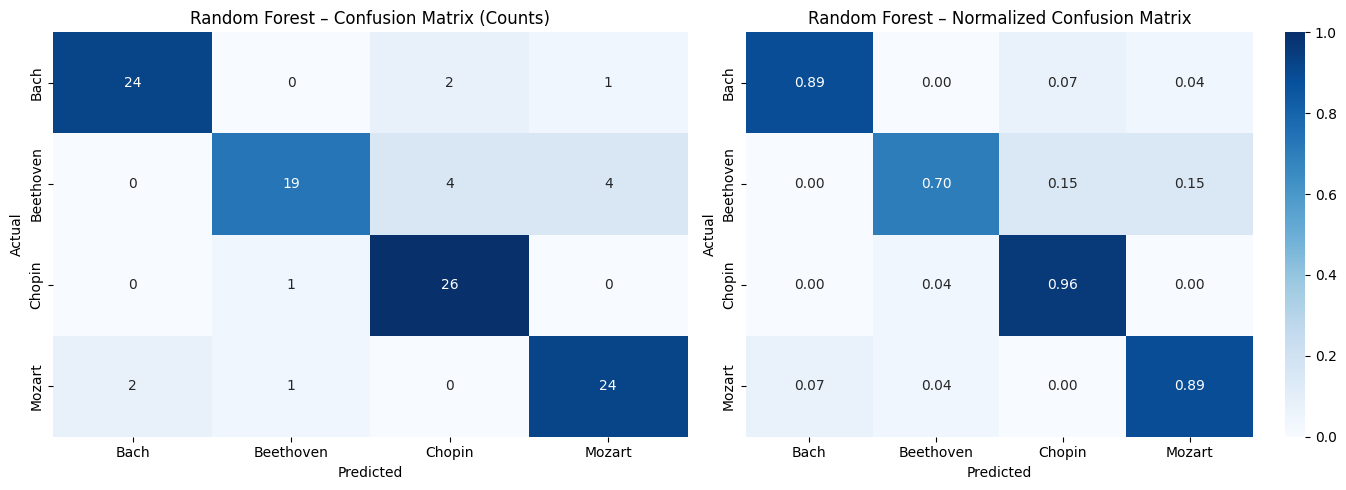

Saved: scorematch_artifacts/final_136_80_20_20fps/evaluation/svm_confusion_matrices.png


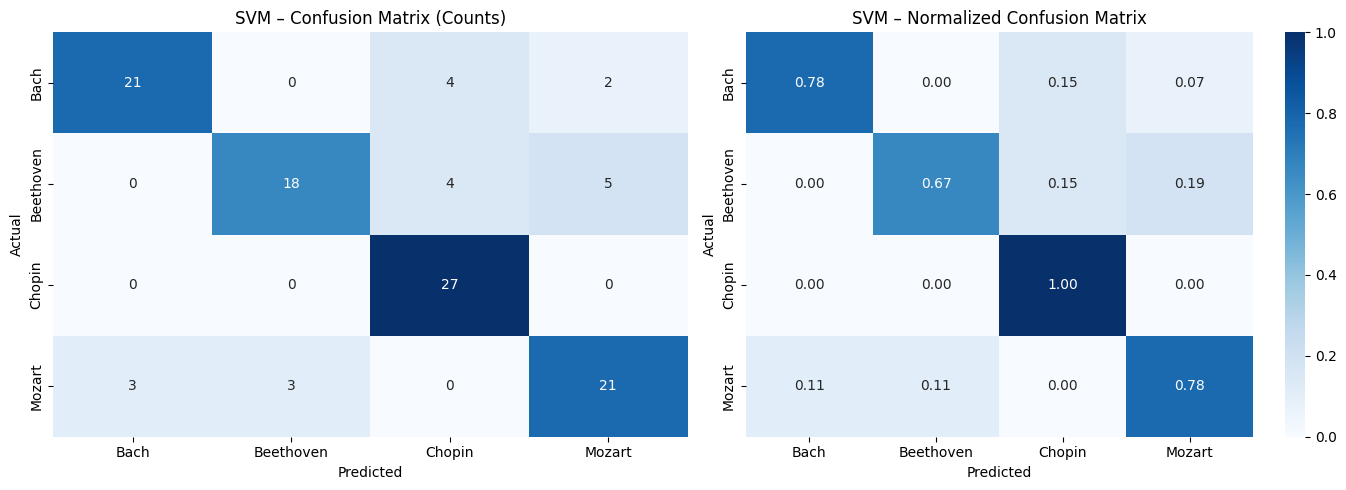

Saved: scorematch_artifacts/final_136_80_20_20fps/evaluation/logistic regression_confusion_matrices.png


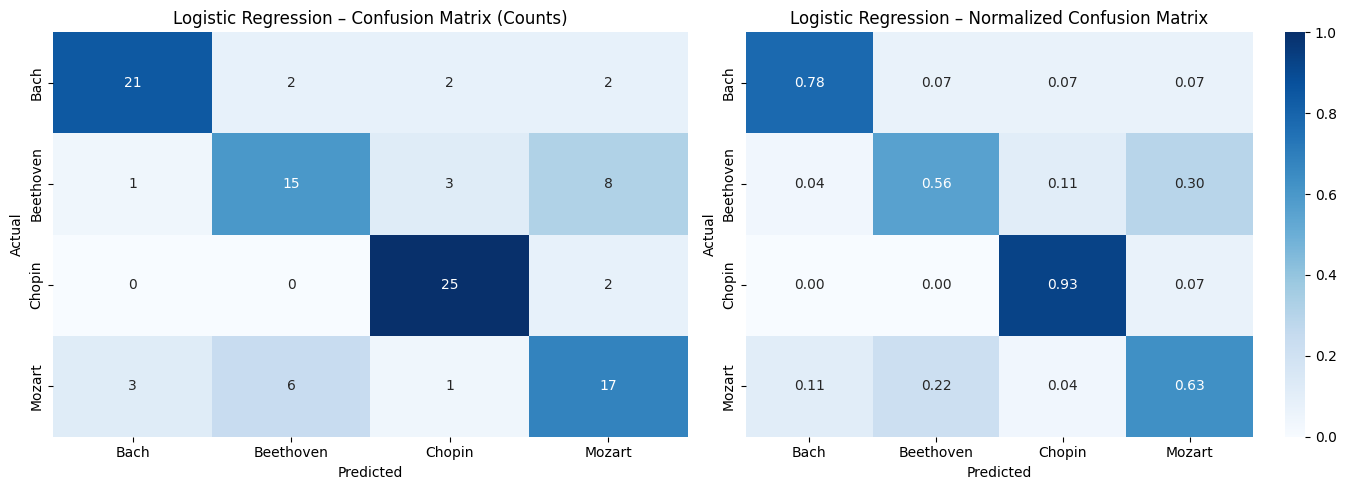

In [ ]:
# Create and display confusion matrices for both models.
# One matrix shows raw counts; the other shows row-normalized percentages.

def plot_confusion_matrices(y_true, y_pred, model_name, composers, save_dir):
    """
    Plot raw-count and normalized confusion matrices side-by-side.
    """
    cm = confusion_matrix(y_true, y_pred, labels=composers)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Raw counts
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=composers,
        yticklabels=composers,
        ax=axes[0],
        cbar=False
    )
    axes[0].set_title(f"{model_name} – Confusion Matrix (Counts)")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    # Normalized (row percentages)
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=composers,
        yticklabels=composers,
        ax=axes[1],
        vmin=0.0,
        vmax=1.0
    )
    axes[1].set_title(f"{model_name} – Normalized Confusion Matrix")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")

    plt.tight_layout()

    # Save figure
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    safe_name = model_name.lower().replace("-", "_")
    fig_path = save_dir / f"{safe_name}_confusion_matrices.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {fig_path}")
    plt.show()

    return cm, cm_norm


# Directory for evaluation artifacts
EVAL_DIR = Path("scorematch_artifacts/final_136_80_20_20fps/evaluation")
EVAL_DIR.mkdir(parents=True, exist_ok=True)

# Generate matrices for both models
cm_cnn, cm_cnn_norm = plot_confusion_matrices(
    cnn_metrics["y_true"],
    cnn_metrics["y_pred"],
    "CNN",
    COMPOSERS,
    EVAL_DIR
)

cm_lstm, cm_lstm_norm = plot_confusion_matrices(
    cnn_lstm_metrics["y_true"],
    cnn_lstm_metrics["y_pred"],
    "CNN-LSTM",
    COMPOSERS,
    EVAL_DIR
)

# Classical classifiers
cm_rf, cm_rf_norm = plot_confusion_matrices(
    classical_predictions["Random Forest"]["y_true"],
    classical_predictions["Random Forest"]["y_pred"],
    "Random Forest",
    COMPOSERS,
    EVAL_DIR
)

cm_svm, cm_svm_norm = plot_confusion_matrices(
    classical_predictions["Support Vector Machine"]["y_true"],
    classical_predictions["Support Vector Machine"]["y_pred"],
    "SVM",
    COMPOSERS,
    EVAL_DIR
)

cm_lr, cm_lr_norm = plot_confusion_matrices(
    classical_predictions["Logistic Regression"]["y_true"],
    classical_predictions["Logistic Regression"]["y_pred"],
    "Logistic Regression",
    COMPOSERS,
    EVAL_DIR
)

### Confusion Matrix Notes

Beethoven was the most difficult composer for both deep models and was most frequently misclassified as Mozart. The CNN also showed some confusion between Bach and Chopin or Mozart, while the CNN-LSTM frequently confused Beethoven with both Mozart and Chopin. Overall, the confusion patterns show that Beethoven was harder to separate from the other composers.

### 4. Most Frequent Misclassifications

Off-diagonal cells from the confusion matrices are ranked by how often each error occurs. The largest error for both deep models is Beethoven → Mozart. Beethoven → Chopin is also a major source of error, particularly for the CNN-LSTM.

In [ ]:
# Identify the most common incorrect predictions.
# This shows which composer pairs the models confuse most often.

def get_top_confusions(cm, composers, top_k=5):
    """
    Return a list of the top-k most frequent misclassifications.
    """
    confusions = []
    n = len(composers)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            count = int(cm[i, j])
            if count > 0:
                confusions.append({
                    "actual": composers[i],
                    "predicted": composers[j],
                    "count": count
                })
    # Sort by frequency (descending)
    confusions = sorted(confusions, key=lambda x: x["count"], reverse=True)
    return confusions[:top_k]


print("=" * 70)
print("Most frequent confusions – CNN")
print("=" * 70)
for item in get_top_confusions(cm_cnn, COMPOSERS):
    print(f"  {item['actual']:10s} → {item['predicted']:10s} : {item['count']} files")

print("\n" + "=" * 70)
print("Most frequent confusions – CNN-LSTM")
print("=" * 70)
for item in get_top_confusions(cm_lstm, COMPOSERS):
    print(f"  {item['actual']:10s} → {item['predicted']:10s} : {item['count']} files")

Most frequent confusions – CNN
  Beethoven  → Mozart     : 10 files
  Beethoven  → Chopin     : 4 files
  Bach       → Chopin     : 3 files
  Bach       → Mozart     : 3 files
  Mozart     → Beethoven  : 3 files

Most frequent confusions – CNN-LSTM
  Beethoven  → Mozart     : 7 files
  Beethoven  → Chopin     : 6 files
  Bach       → Chopin     : 3 files
  Mozart     → Bach       : 3 files
  Chopin     → Beethoven  : 2 files


### Main Confusions

The most consistent error across both deep models was Beethoven → Mozart. Beethoven → Chopin was also frequent, especially for the CNN-LSTM. These results suggest that Beethoven was more difficult for the models to distinguish from the other composers using the selected MIDI representations.

### 5. Model Comparison Table

Side-by-side results for the three traditional baselines (Random Forest, SVM, Logistic Regression)  
and the two deep models (CNN, CNN-LSTM).  
Sorted by macro-F1. The table is saved for the report.

In [ ]:
# Compare the classical baselines with the 10-second deep models
# using the results generated earlier in the notebook.

baseline_compare = baseline_results_df[
    [
        "model",
        "accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
    ]
].copy()

deep_compare = pd.DataFrame([
    {
        "model": "CNN (20 FPS, 10 s)",
        "accuracy": cnn_metrics["accuracy"],
        "macro_precision": cnn_metrics["macro_precision"],
        "macro_recall": cnn_metrics["macro_recall"],
        "macro_f1": cnn_metrics["macro_f1"],
    },
    {
        "model": "CNN-LSTM (20 FPS, 10 s)",
        "accuracy": cnn_lstm_metrics["accuracy"],
        "macro_precision": cnn_lstm_metrics["macro_precision"],
        "macro_recall": cnn_lstm_metrics["macro_recall"],
        "macro_f1": cnn_lstm_metrics["macro_f1"],
    },
])

comparison_df = pd.concat(
    [baseline_compare, deep_compare],
    ignore_index=True
)

comparison_df = comparison_df.sort_values(
    ["macro_f1", "accuracy"],
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("Model Comparison – Shared Test Set")
print("=" * 70)

display(comparison_df)

comparison_path = EVAL_DIR / "final_model_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)

print("\nSaved comparison table:", comparison_path)

Model Comparison – Shared Test Set


,model,accuracy,macro_precision,macro_recall,macro_f1
0,Random Forest,0.861111,0.866981,0.861111,0.858956
1,Support Vector Machine,0.805556,0.813393,0.805556,0.802033
2,"CNN-LSTM (20 FPS, 10 s)",0.768519,0.772559,0.768519,0.761501
3,"CNN (20 FPS, 10 s)",0.731481,0.750025,0.731481,0.727298
4,Logistic Regression,0.722222,0.721208,0.722222,0.719226



Saved comparison table: scorematch_artifacts/full_dataset_rf/final_model_comparison.csv


### Comparison Summary

Random Forest produced the strongest performance on the shared balanced test set, reaching 0.8611 accuracy and 0.8590 macro-F1. The Support Vector Machine ranked second with 0.8056 accuracy and 0.8020 macro-F1. Among the 10-second deep-learning models, CNN-LSTM outperformed CNN, reaching 0.7685 accuracy and 0.7615 macro-F1. Overall, the engineered MIDI features used by the classical models were especially effective for composer classification.

## Experiment: 15-Second Piano-Roll Segments

Previous models used 10-second excerpts.  
Here we rebuild the piano-roll cache at 20 FPS with 15-second (300-frame) segments to test whether longer context helps.  
Everything else (splits, seed, composers) stays the same.

In [ ]:
# BUILD the real 15-second (300-frame) piano-roll cache to see if we can optimize the model

import time
from pathlib import Path

PIANO_ROLL_FPS = 20
SEGMENT_SECONDS = 15.0
TARGET_FRAMES = 300

ARTIFACT_DIR = Path("scorematch_artifacts") / f"final_{FILES_PER_COMPOSER}_80_20_{PIANO_ROLL_FPS}fps_15s"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

PIANO_ROLL_CACHE_PATH = ARTIFACT_DIR / f"piano_roll_cache_{PIANO_ROLL_FPS}fps_{TARGET_FRAMES}frames.npy"
expected_shape = (len(midi_df), 128, TARGET_FRAMES)

print("Building 15-second cache")
print("Target shape :", expected_shape)
print("Save path    :", PIANO_ROLL_CACHE_PATH)
print()

piano_roll_array = np.empty(expected_shape, dtype=np.uint8)
started = time.time()

for position, file_path in enumerate(midi_df["file_path"]):
    piano_roll_array[position] = create_piano_roll_segment_uint8(
        file_path,
        frames_per_second=PIANO_ROLL_FPS,
        segment_seconds=SEGMENT_SECONDS,
        random_state=SEED,
    )
    if (position + 1) % 50 == 0 or (position + 1) == len(midi_df):
        print(f"  Prepared {position + 1}/{len(midi_df)}")

np.save(PIANO_ROLL_CACHE_PATH, piano_roll_array)
print(f"\nSaved in {(time.time() - started)/60:.1f} minutes")
print(PIANO_ROLL_CACHE_PATH)

# Load the new cache into memory
all_piano_rolls_uint8 = np.load(PIANO_ROLL_CACHE_PATH, mmap_mode="r")

print("\n===== FINAL CHECK =====")
print("all_piano_rolls_uint8.shape :", all_piano_rolls_uint8.shape)

if all_piano_rolls_uint8.shape == expected_shape:
    print("SUCCESS – 15-second (300-frame) cache is ready.")
else:
    print("ERROR – shape is still wrong.")

Building 15-second cache
Target shape : (544, 128, 300)
Save path    : scorematch_artifacts/final_136_80_20_20fps_15s/piano_roll_cache_20fps_300frames.npy

  Prepared 50/544
  Prepared 100/544
  Prepared 150/544
  Prepared 200/544
  Prepared 250/544
  Prepared 300/544
  Prepared 350/544
  Prepared 400/544
  Prepared 450/544
  Prepared 500/544
  Prepared 544/544

Saved in 2.8 minutes
scorematch_artifacts/final_136_80_20_20fps_15s/piano_roll_cache_20fps_300frames.npy

===== FINAL CHECK =====
all_piano_rolls_uint8.shape : (544, 128, 300)
SUCCESS – 15-second (300-frame) cache is ready.


### 10 s vs 15 s

Increasing the segment length from 10 to 15 seconds improved the CNN macro-F1 from 0.7273 to 0.7776 and test accuracy from 0.7315 to 0.7778. The CNN-LSTM moved in the opposite direction, with macro-F1 decreasing from 0.7615 to 0.7485. Longer context therefore helped the CNN but did not benefit the CNN-LSTM. The 15-second CNN was the strongest pure deep-learning configuration tested.

### Rebuild DataLoaders for 300-Frame Inputs

Recreate the datasets and loaders so they pull the new 15-second piano rolls.  
Class weights are recalculated from the training split.

Using cache shape: (544, 128, 300)

Sample piano-roll shape: (1, 128, 300)
Expected frames: 300
Source file: /content/scorematch_data/archive/Chopin/Nocturne op48 n1.mid


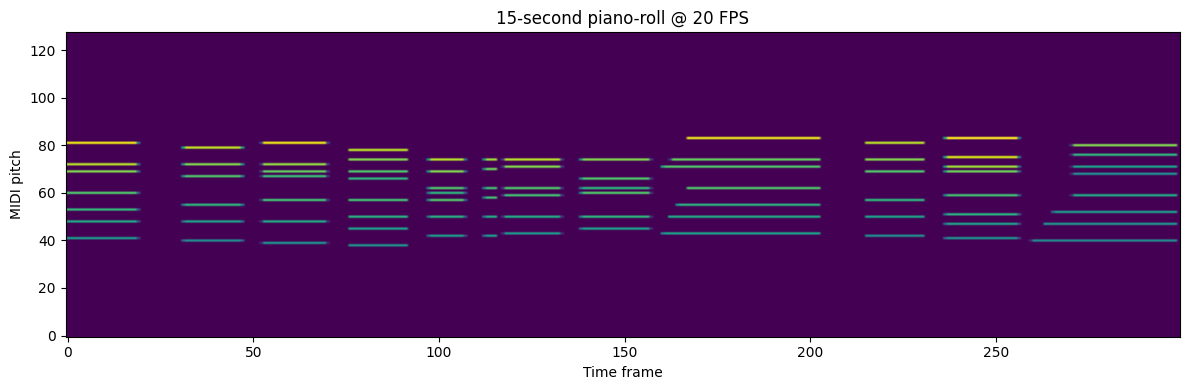

In [ ]:
# Rebuild DataLoaders with the new 300-frame cache

print("Using cache shape:", all_piano_rolls_uint8.shape)
assert all_piano_rolls_uint8.shape[2] == 300, "Cache is not 300 frames!"

# Re-create loaders (uses the current all_piano_rolls_uint8)
(
    train_dataset,
    validation_dataset,
    test_dataset,
    train_loader,
    validation_loader,
    test_loader,
) = make_data_loaders()

# Re-compute class weights
training_label_counts = np.bincount(
    y_encoded[train_positions],
    minlength=len(label_encoder.classes_),
)
class_weights = len(train_positions) / (len(label_encoder.classes_) * training_label_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)

# Visual + shape confirmation
sample_roll, sample_features, sample_label, sample_path = validation_dataset[0]
print("\nSample piano-roll shape:", tuple(sample_roll.shape))
print("Expected frames: 300")
print("Source file:", sample_path)

plt.figure(figsize=(12, 4))
plt.imshow(sample_roll.squeeze(0).numpy(), aspect="auto", origin="lower")
plt.title("15-second piano-roll @ 20 FPS")
plt.xlabel("Time frame")
plt.ylabel("MIDI pitch")
plt.tight_layout()
plt.show()

### Train CNN and CNN-LSTM on 15-Second Segments

Retrain both models from scratch on the longer inputs.  
Same optimizer, early stopping, and class-weighted loss as before.  
Checkpoints and training curves are saved.

In [ ]:
# Train CNN and CNN-LSTM on true 15-second segments

trained_models = {}
training_histories = {}
checkpoint_paths = {}
training_metadata = {}

for model_name, builder in model_builders.items():
    reset_experiment_seed(SEED)

    print("\n" + "=" * 80)
    print(f"Training {model_name} | 20 FPS | 15-second segments")
    print("=" * 80)

    (
        trained_model,
        history_frame,
        checkpoint_path,
        elapsed_seconds,
        best_validation_f1,
    ) = train_scorematch_model(model_name, builder())

    trained_models[model_name] = trained_model
    training_histories[model_name] = history_frame
    checkpoint_paths[model_name] = checkpoint_path
    training_metadata[model_name] = {
        "training_seconds": elapsed_seconds,
        "best_validation_macro_f1": best_validation_f1,
    }

print("\nTraining complete.")
print("Checkpoints saved in:", ARTIFACT_DIR)


Training CNN | 20 FPS | 15-second segments
CNN | Epoch 01/15 | train loss 1.3802 | train acc 0.3291 | val loss 1.2771 | val acc 0.2955 | val F1 0.1807
CNN | Epoch 02/15 | train loss 1.0238 | train acc 0.5408 | val loss 0.9059 | val acc 0.6818 | val F1 0.6687
CNN | Epoch 03/15 | train loss 0.7554 | train acc 0.6862 | val loss 0.6844 | val acc 0.7273 | val F1 0.7292
CNN | Epoch 04/15 | train loss 0.6512 | train acc 0.7321 | val loss 0.5841 | val acc 0.7500 | val F1 0.7402
CNN | Epoch 05/15 | train loss 0.5638 | train acc 0.7832 | val loss 0.6448 | val acc 0.7273 | val F1 0.7296
CNN | Epoch 06/15 | train loss 0.5843 | train acc 0.7551 | val loss 0.6337 | val acc 0.6818 | val F1 0.6739
CNN | Epoch 07/15 | train loss 0.4190 | train acc 0.8469 | val loss 0.5884 | val acc 0.7500 | val F1 0.7492
CNN | Epoch 08/15 | train loss 0.3958 | train acc 0.8418 | val loss 0.6314 | val acc 0.7500 | val F1 0.7465
CNN | Epoch 09/15 | train loss 0.3546 | train acc 0.8597 | val loss 0.5544 | val acc 0.7955 

### Test-Set Evaluation of the 15-Second Models

Test loss, accuracy, macro-F1, and best validation macro-F1 for both models.  
These are compared directly with the 10-second results.

In [ ]:
# Final test-set evaluation on the true 15-second models

criterion_for_testing = nn.CrossEntropyLoss(weight=class_weights_tensor)

# ------------------------------------------------------------------
# 1. Load the 10-second results that were saved in the earlier run
# ------------------------------------------------------------------
RESULTS_10S_PATH = Path(
    "scorematch_artifacts/final_136_80_20_20fps/final_20fps_model_results.csv"
)

if not RESULTS_10S_PATH.exists():
    raise FileNotFoundError(
        f"Could not find the 10-second results file:\n{RESULTS_10S_PATH}\n"
        "Re-run the earlier evaluation cell or update the path."
    )

results_10s_df = pd.read_csv(RESULTS_10S_PATH)

print("=" * 70)
print("10-SECOND SEGMENT RESULTS (loaded from previous run)")
print("=" * 70)
display(results_10s_df[["model", "segment_seconds", "test_accuracy", "macro_f1", "best_validation_macro_f1"]])

# ------------------------------------------------------------------
# 2. Evaluate the models trained on 15-second segments
# ------------------------------------------------------------------
model_results = []
prediction_frames = []

for model_name, model in trained_models.items():
    test_metrics = evaluate_model(
        model,
        test_loader,
        criterion_for_testing,
        return_predictions=True,
    )

    macro_precision = precision_score(
        test_metrics["labels"], test_metrics["predictions"],
        average="macro", zero_division=0
    )
    macro_recall = recall_score(
        test_metrics["labels"], test_metrics["predictions"],
        average="macro", zero_division=0
    )
    macro_f1 = test_metrics["macro_f1"]

    model_results.append({
        "model": model_name,
        "fps": PIANO_ROLL_FPS,
        "segment_seconds": SEGMENT_SECONDS,          # 15.0
        "test_loss": test_metrics["loss"],
        "test_accuracy": test_metrics["accuracy"],
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "best_validation_macro_f1": training_metadata[model_name]["best_validation_macro_f1"],
        "training_seconds": training_metadata[model_name]["training_seconds"],
        "checkpoint": str(checkpoint_paths[model_name]),
    })

    prediction_frames.append(pd.DataFrame({
        "model": model_name,
        "fps": PIANO_ROLL_FPS,
        "segment_seconds": SEGMENT_SECONDS,
        "file_path": test_metrics["file_paths"],
        "actual_composer": label_encoder.inverse_transform(test_metrics["labels"]),
        "predicted_composer": label_encoder.inverse_transform(test_metrics["predictions"]),
    }))

print("\n" + "=" * 70)
print("15-SECOND SEGMENT RESULTS (current run)")
print("=" * 70)
results_15s_df = pd.DataFrame(model_results)
display(results_15s_df[["model", "segment_seconds", "test_accuracy", "macro_f1", "best_validation_macro_f1"]])

# 3. Side-by-side comparison
# Select the columns of interest from both runs

cols = ["model", "segment_seconds", "test_accuracy", "macro_f1", "best_validation_macro_f1"]

comparison_df = pd.concat(
    [
        results_10s_df[cols],
        results_15s_df[cols],
    ],
    ignore_index=True
).sort_values(["model", "segment_seconds"]).reset_index(drop=True)

print("\n" + "=" * 70)
print("SIDE-BY-SIDE COMPARISON (10 s vs 15 s)")
print("=" * 70)
display(comparison_df)

# 4. Save artifacts

final_results_df = results_15s_df.sort_values(
    ["test_accuracy", "macro_f1"], ascending=False
).reset_index(drop=True)

results_path = ARTIFACT_DIR / "final_15s_model_results.csv"
final_results_df.to_csv(results_path, index=False)

test_predictions_df = pd.concat(prediction_frames, ignore_index=True)
pred_path = ARTIFACT_DIR / "test_predictions_for_evaluation.csv"
test_predictions_df.to_csv(pred_path, index=False)

comparison_path = ARTIFACT_DIR / "segment_length_comparison_10s_vs_15s.csv"
comparison_df.to_csv(comparison_path, index=False)

print("\nSaved 15 s results :", results_path)
print("Saved predictions  :", pred_path)
print("Saved comparison   :", comparison_path)

10-SECOND SEGMENT RESULTS (loaded from previous run)


,model,segment_seconds,test_accuracy,macro_f1,best_validation_macro_f1
0,CNN-LSTM,10.0,0.768519,0.761501,0.864456
1,CNN,10.0,0.731481,0.727298,0.820367



15-SECOND SEGMENT RESULTS (current run)


,model,segment_seconds,test_accuracy,macro_f1,best_validation_macro_f1
0,CNN,15.0,0.777778,0.777578,0.839686
1,CNN-LSTM,15.0,0.750000,0.748538,0.887391



SIDE-BY-SIDE COMPARISON (10 s vs 15 s)


,model,segment_seconds,test_accuracy,macro_f1,best_validation_macro_f1
0,CNN,10.0,0.731481,0.727298,0.820367
1,CNN,15.0,0.777778,0.777578,0.839686
2,CNN-LSTM,10.0,0.768519,0.761501,0.864456
3,CNN-LSTM,15.0,0.750000,0.748538,0.887391



Saved 15 s results : scorematch_artifacts/final_136_80_20_20fps_15s/final_15s_model_results.csv
Saved predictions  : scorematch_artifacts/final_136_80_20_20fps_15s/test_predictions_for_evaluation.csv
Saved comparison   : scorematch_artifacts/final_136_80_20_20fps_15s/segment_length_comparison_10s_vs_15s.csv


## Iteration: Piano-Roll Augmentation Experiment

Re-uses the existing piano-roll cache and splits.  
This augmentation approach (pitch shift, time shift, velocity scaling on the training set only) was suggested during AI-assisted troubleshooting and brainstorming on how to improve the model. The CNN is re-trained to test whether it improves performance.

In [ ]:
# Augmentation utilities and Dataset (new experiment – does not modify earlier cells)

def augment_piano_roll(roll, max_pitch_shift=4, max_time_shift_frames=20, velocity_scale_range=(0.75, 1.25)):
    """Apply pitch shift, time shift, and velocity scaling to one piano-roll."""
    if isinstance(roll, torch.Tensor):
        roll = roll.numpy()
    roll = roll.copy()

    has_channel = (roll.ndim == 3)
    if has_channel:
        roll = roll.squeeze(0)          # (128, T)

    n_pitches, n_frames = roll.shape

    # Pitch shift
    shift = np.random.randint(-max_pitch_shift, max_pitch_shift + 1)
    if shift > 0:
        roll = np.vstack([np.zeros((shift, n_frames)), roll[:-shift, :]])
    elif shift < 0:
        roll = np.vstack([roll[-shift:, :], np.zeros((-shift, n_frames))])

    # Time shift (circular)
    t_shift = np.random.randint(-max_time_shift_frames, max_time_shift_frames + 1)
    roll = np.roll(roll, t_shift, axis=1)

    # Velocity scaling
    scale = np.random.uniform(*velocity_scale_range)
    roll = np.clip(roll * scale, 0, 127).astype(roll.dtype)

    if has_channel:
        roll = roll[np.newaxis, ...]
    return roll


class AugmentedPianoRollDataset(Dataset):
    def __init__(self, piano_rolls, labels, augment=False):
        self.piano_rolls = piano_rolls
        self.labels = labels
        self.augment = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        roll = self.piano_rolls[idx]
        label = self.labels[idx]

        if self.augment:
            roll = augment_piano_roll(roll)

        if isinstance(roll, np.ndarray):
            roll = torch.from_numpy(roll).float()
        if roll.ndim == 2:
            roll = roll.unsqueeze(0)    # (1, 128, T)

        return roll, torch.tensor(label, dtype=torch.long)

In [ ]:
# Re-create loaders using the existing PrecomputedPianoRollDataset
# Augmentation is applied only when training=True

train_dataset_aug = PrecomputedPianoRollDataset(
    dataframe = midi_df,
    positions = train_positions,
    piano_rolls_uint8 = all_piano_rolls_uint8,
    engineered_features = all_engineered_features,
    encoded_labels = y_encoded,
    training = True          # ← augmentation ON
)

val_dataset_aug = PrecomputedPianoRollDataset(
    dataframe = midi_df,
    positions = validation_positions,
    piano_rolls_uint8 = all_piano_rolls_uint8,
    engineered_features = all_engineered_features,
    encoded_labels = y_encoded,
    training = False
)

test_dataset_aug = PrecomputedPianoRollDataset(
    dataframe = midi_df,
    positions = test_positions,
    piano_rolls_uint8 = all_piano_rolls_uint8,
    engineered_features = all_engineered_features,
    encoded_labels = y_encoded,
    training = False
)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=16, shuffle=True)
val_loader_aug   = DataLoader(val_dataset_aug,   batch_size=16, shuffle=False)
test_loader_aug  = DataLoader(test_dataset_aug,  batch_size=16, shuffle=False)

print("Train batches (augmented):", len(train_loader_aug))
print("Val batches:", len(val_loader_aug))
print("Test batches:", len(test_loader_aug))

Train batches (augmented): 25
Val batches: 3
Test batches: 7


In [ ]:
# Train ScoreMatchCNN with existing augmentation.
# Float32 casting was added after a dtype mismatch error; AI helped identify the fix.

reset_experiment_seed(SEED)

model_aug = ScoreMatchCNN(
    engineered_feature_count = all_engineered_features.shape[1],
    number_of_classes = len(label_encoder.classes_)
).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model_aug.parameters(), lr=1e-3)

best_val_f1 = 0.0
best_state = None
patience = 12
wait = 0

NUM_EPOCHS = 30

for epoch in range(1, NUM_EPOCHS + 1):
    # ---- train ----
    model_aug.train()
    running_loss = 0.0

    for piano_roll, engineered_features, yb, _ in train_loader_aug:
        # Force float32 – this troubleshooting required AI to solve
        piano_roll = piano_roll.float().to(DEVICE)
        engineered_features = engineered_features.float().to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model_aug(piano_roll, engineered_features)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * piano_roll.size(0)

    train_loss = running_loss / len(train_loader_aug.dataset)

    # ---- validate ----
    model_aug.eval()
    val_preds, val_labels = [], []
    with torch.no_grad():
        for piano_roll, engineered_features, yb, _ in val_loader_aug:
            piano_roll = piano_roll.float().to(DEVICE)
            engineered_features = engineered_features.float().to(DEVICE)

            logits = model_aug(piano_roll, engineered_features)
            preds = logits.argmax(dim=1).cpu().numpy()
            val_preds.extend(preds)
            val_labels.extend(yb.numpy())

    val_f1 = f1_score(val_labels, val_preds, average="macro")
    print(f"Epoch {epoch:02d} | train loss {train_loss:.4f} | val macro-F1 {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = copy.deepcopy(model_aug.state_dict())
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

model_aug.load_state_dict(best_state)
print(f"\nBest validation macro-F1: {best_val_f1:.4f}")

Epoch 01 | train loss 1.3724 | val macro-F1 0.5185
Epoch 02 | train loss 1.0732 | val macro-F1 0.6863
Epoch 03 | train loss 0.7681 | val macro-F1 0.7446
Epoch 04 | train loss 0.6592 | val macro-F1 0.6622
Epoch 05 | train loss 0.6105 | val macro-F1 0.7708
Epoch 06 | train loss 0.5312 | val macro-F1 0.7927
Epoch 07 | train loss 0.4327 | val macro-F1 0.8204
Epoch 08 | train loss 0.3953 | val macro-F1 0.7707
Epoch 09 | train loss 0.3886 | val macro-F1 0.8388
Epoch 10 | train loss 0.2917 | val macro-F1 0.8397
Epoch 11 | train loss 0.2723 | val macro-F1 0.7947
Epoch 12 | train loss 0.2335 | val macro-F1 0.8650
Epoch 13 | train loss 0.1873 | val macro-F1 0.8424
Epoch 14 | train loss 0.2432 | val macro-F1 0.7680
Epoch 15 | train loss 0.1776 | val macro-F1 0.7967
Epoch 16 | train loss 0.1944 | val macro-F1 0.8192
Epoch 17 | train loss 0.1498 | val macro-F1 0.8638
Epoch 18 | train loss 0.1509 | val macro-F1 0.7968
Epoch 19 | train loss 0.1508 | val macro-F1 0.8621
Epoch 20 | train loss 0.1102 | 

In [ ]:
# Test-set evaluation of the augmented CNN

model_aug.eval()
test_preds, test_labels = [], []

with torch.no_grad():
    for piano_roll, engineered_features, yb, _ in test_loader_aug:
        piano_roll = piano_roll.float().to(DEVICE)
        engineered_features = engineered_features.float().to(DEVICE)

        logits = model_aug(piano_roll, engineered_features)
        preds = logits.argmax(dim=1).cpu().numpy()
        test_preds.extend(preds)
        test_labels.extend(yb.numpy())

test_acc = accuracy_score(test_labels, test_preds)
test_f1  = f1_score(test_labels, test_preds, average="macro")

print("=" * 60)
print("CNN + Augmentation – Test Results")
print("=" * 60)
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Macro-F1      : {test_f1:.4f}")
print(f"Best Val F1   : {best_val_f1:.4f}")
print()
print(classification_report(
    test_labels, test_preds,
    target_names=label_encoder.classes_,
    digits=4
))

CNN + Augmentation – Test Results
Test Accuracy : 0.7593
Macro-F1      : 0.7579
Best Val F1   : 0.8650

              precision    recall  f1-score   support

        Bach     0.9167    0.8148    0.8627        27
   Beethoven     0.7500    0.5556    0.6383        27
      Chopin     0.8000    0.8889    0.8421        27
      Mozart     0.6176    0.7778    0.6885        27

    accuracy                         0.7593       108
   macro avg     0.7711    0.7593    0.7579       108
weighted avg     0.7711    0.7593    0.7579       108



### Augmentation Result

Stronger pitch, time, and velocity augmentation did not improve the 15-second CNN. Test macro-F1 decreased from 0.7776 for the standard 15-second CNN to 0.7579 with augmentation, despite the augmented model reaching a strong validation score. This suggests that the additional variation did not improve generalization to the held-out test set.

In [ ]:
# Helper: extract the 256-dimensional embedding from ScoreMatchCNN

def extract_cnn_embedding(model, piano_roll, engineered_features):
    """
    Returns the 256-dim vector that is produced after the first
    Linear + ReLU inside the classifier head.
    """
    model.eval()
    with torch.no_grad():
        # Piano-roll path
        roll_emb = model.piano_roll_encoder(piano_roll)
        roll_emb = torch.flatten(roll_emb, start_dim=1)

        # Engineered-feature path
        feat_emb = model.feature_branch(engineered_features)

        # Combine exactly as the model does
        combined = torch.cat([roll_emb, feat_emb], dim=1)

        # First Linear (→ 256) + ReLU  (this is the embedding we want)
        emb = model.classifier[0](combined)   # Linear
        emb = model.classifier[1](emb)        # ReLU

    return emb.cpu().numpy()

In [ ]:
# Extract embeddings + keep the original engineered features

def collect_hybrid_features(model, loader):
    embeddings = []
    engineered = []
    labels = []

    model.eval()
    with torch.no_grad():
        for piano_roll, eng_feats, yb, _ in loader:
            piano_roll = piano_roll.float().to(DEVICE)
            eng_feats  = eng_feats.float().to(DEVICE)

            emb = extract_cnn_embedding(model, piano_roll, eng_feats)
            embeddings.append(emb)
            engineered.append(eng_feats.cpu().numpy())
            labels.append(yb.numpy())

    X_emb = np.vstack(embeddings)
    X_eng = np.vstack(engineered)
    y     = np.concatenate(labels)

    # Concatenate CNN embedding with original engineered features
    X_hybrid = np.hstack([X_emb, X_eng])
    return X_hybrid, y


print("Extracting hybrid features...")
X_train_hyb, y_train_hyb = collect_hybrid_features(model_aug, train_loader_aug)
X_val_hyb,   y_val_hyb   = collect_hybrid_features(model_aug, val_loader_aug)
X_test_hyb,  y_test_hyb  = collect_hybrid_features(model_aug, test_loader_aug)

print("Train hybrid shape:", X_train_hyb.shape)
print("Val   hybrid shape:", X_val_hyb.shape)
print("Test  hybrid shape:", X_test_hyb.shape)

Extracting hybrid features...
Train hybrid shape: (392, 298)
Val   hybrid shape: (44, 298)
Test  hybrid shape: (108, 298)


In [ ]:
# Train Random Forest (and Logistic Regression) on the hybrid features

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Scale the hybrid features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_hyb)
X_val_scaled   = scaler.transform(X_val_hyb)
X_test_scaled  = scaler.transform(X_test_hyb)

# --- Random Forest ---
rf_hybrid = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)
rf_hybrid.fit(X_train_hyb, y_train_hyb)   # RF does not need scaling

rf_pred = rf_hybrid.predict(X_test_hyb)
rf_acc  = accuracy_score(y_test_hyb, rf_pred)
rf_f1   = f1_score(y_test_hyb, rf_pred, average="macro")

print("=" * 60)
print("Hybrid Random Forest (CNN embedding + engineered features)")
print("=" * 60)
print(f"Test Accuracy : {rf_acc:.4f}")
print(f"Macro-F1      : {rf_f1:.4f}")
print(classification_report(
    y_test_hyb, rf_pred,
    target_names=label_encoder.classes_,
    digits=4
))

# --- Logistic Regression (optional but useful comparison) ---
lr_hybrid = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=SEED
)
lr_hybrid.fit(X_train_scaled, y_train_hyb)

lr_pred = lr_hybrid.predict(X_test_scaled)
lr_acc  = accuracy_score(y_test_hyb, lr_pred)
lr_f1   = f1_score(y_test_hyb, lr_pred, average="macro")

print("=" * 60)
print("Hybrid Logistic Regression")
print("=" * 60)
print(f"Test Accuracy : {lr_acc:.4f}")
print(f"Macro-F1      : {lr_f1:.4f}")

Hybrid Random Forest (CNN embedding + engineered features)
Test Accuracy : 0.7870
Macro-F1      : 0.7866
              precision    recall  f1-score   support

        Bach     0.9167    0.8148    0.8627        27
   Beethoven     0.7500    0.6667    0.7059        27
      Chopin     0.7742    0.8889    0.8276        27
      Mozart     0.7241    0.7778    0.7500        27

    accuracy                         0.7870       108
   macro avg     0.7912    0.7870    0.7866       108
weighted avg     0.7912    0.7870    0.7866       108

Hybrid Logistic Regression
Test Accuracy : 0.7870
Macro-F1      : 0.7850


### Hybrid Feature Result

Combining CNN embeddings with the engineered MIDI features improved performance relative to the pure deep models. The hybrid Random Forest reached 0.7870 accuracy and 0.7866 macro-F1, while the hybrid Logistic Regression reached 0.7870 accuracy and 0.7850 macro-F1. However, neither hybrid model surpassed the original Random Forest or SVM baselines, suggesting that the engineered MIDI features already captured much of the useful classification signal.

## Experiment: Full Imbalanced Dataset

Earlier experiments used a balanced subset of 136 files per composer, or 544 files total. This experiment uses all 1,628 valid MIDI files available after unreadable files were removed: 1,024 Bach, 212 Beethoven, 136 Chopin, and 256 Mozart files. Stratified splitting and class weighting are used to address the imbalance, while macro-F1 remains the primary metric for comparing balanced performance across composers.

In [ ]:
# 1. Load EVERY available MIDI file (remove the 136-per-composer limit)

print("Building full unbalanced dataset...")

# Re-use the same folder structure that was already extracted
FULL_DATASET_DIR = EXTRACTION_DIRECTORY / "archive"  # Path that contains Bach/ Beethoven/ etc.

full_midi_df = build_midi_dataset(
    dataset_directory = FULL_DATASET_DIR,
    max_files_per_artist = None,          # no cap on composers
    random_state = SEED
)

print("\nFull dataset size:", len(full_midi_df))
print(full_midi_df["artist"].value_counts())

print("\nUsing dataset root:", FULL_DATASET_DIR)
print("Sub-folders:", [p.name for p in FULL_DATASET_DIR.iterdir() if p.is_dir()])

Building full unbalanced dataset...
Found 1024 MIDI files for artist: Bach. Processing 1024.
Found 213 MIDI files for artist: Beethoven. Processing 213.
Could not read /content/scorematch_data/archive/Beethoven/Anhang 14-3.mid: Could not decode key with 3 flats and mode 255
Skipped unreadable file: /content/scorematch_data/archive/Beethoven/Anhang 14-3.mid
Found 136 MIDI files for artist: Chopin. Processing 136.
Found 257 MIDI files for artist: Mozart. Processing 257.
Could not read /content/scorematch_data/archive/Mozart/Piano Sonatas/Nueva carpeta/K281 Piano Sonata n03 3mov.mid: Could not decode key with 2 flats and mode 2
Skipped unreadable file: /content/scorematch_data/archive/Mozart/Piano Sonatas/Nueva carpeta/K281 Piano Sonata n03 3mov.mid

Successfully processed 1628 MIDI files.

Full dataset size: 1628
artist
Bach         1024
Mozart        256
Beethoven     212
Chopin        136
Name: count, dtype: int64

Using dataset root: /content/scorematch_data/archive
Sub-folders: ['Cho

### Stratified Train / Validation / Test Split

The full dataset uses a stratified 80/20 development-test split, followed by a 10% validation split from the development data. This produces 1,171 training files, 131 validation files, and 326 testing files while preserving the overall composer proportions.

In [ ]:
# 2. Stratified 80 % development / 20 % test, then carve validation

# Encode labels
full_label_encoder = LabelEncoder()
full_y = full_label_encoder.fit_transform(full_midi_df["artist"])

# 80 % development / 20 % test (stratified)
dev_idx, test_idx = train_test_split(
    np.arange(len(full_y)),
    test_size = 0.20,
    stratify = full_y,
    random_state = SEED
)

# From development take ~10 % as validation (stratified)
train_idx, val_idx = train_test_split(
    dev_idx,
    test_size = 0.10,
    stratify = full_y[dev_idx],
    random_state = SEED
)

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")
print("\nClass distribution (train):")
print(pd.Series(full_y[train_idx]).value_counts().sort_index())

Train: 1171 | Val: 131 | Test: 326

Class distribution (train):
0    737
1    152
2     98
3    184
Name: count, dtype: int64


### Engineered Feature Extraction on the Full Set

Same MIDI features as before (tempo, pitch stats, velocity, density, pitch-class distribution, etc.) extracted for every file.  
Non-numeric columns dropped, missing values imputed with training medians, then standardized using training-set statistics only.  
The decision to re-run feature extraction on the full unbalanced set and the handling of non-numeric columns were refined with AI assistance.

In [ ]:
# 3. Extract engineered features for the full dataset (fixed)

print("Extracting engineered features for full dataset...")

full_feature_rows = []
for i, row in full_midi_df.iterrows():
    feats = extract_midi_features(row["file_path"])
    if feats is not None:
        feats["file_path"] = row["file_path"]
        feats["artist"] = row["artist"]
        full_feature_rows.append(feats)
    if (i + 1) % 100 == 0:
        print(f"  {i+1}/{len(full_midi_df)}")

full_features_df = pd.DataFrame(full_feature_rows)
print(f"Successfully extracted features for {len(full_features_df)} files")

# Explicitly drop every non-numeric column
non_feature_cols = ["file_path", "artist", "file_name"]
feature_cols = [c for c in full_features_df.columns if c not in non_feature_cols]

# Keep only numeric data
full_engineered = full_features_df[feature_cols].apply(pd.to_numeric, errors="coerce").values.astype(np.float32)

print("Raw engineered matrix shape:", full_engineered.shape)

# Impute + scale using TRAIN statistics only
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(strategy="median")
scaler  = StandardScaler()

full_engineered_train = scaler.fit_transform(
    imputer.fit_transform(full_engineered[train_idx])
)
full_engineered_val   = scaler.transform(
    imputer.transform(full_engineered[val_idx])
)
full_engineered_test  = scaler.transform(
    imputer.transform(full_engineered[test_idx])
)

# Put the scaled features back into a single array in the original order
full_engineered_scaled = np.zeros_like(full_engineered)
full_engineered_scaled[train_idx] = full_engineered_train
full_engineered_scaled[val_idx]   = full_engineered_val
full_engineered_scaled[test_idx]  = full_engineered_test

print("Scaled engineered matrix shape:", full_engineered_scaled.shape)
print("Feature columns used:", len(feature_cols))

Extracting engineered features for full dataset...
  100/1628
  200/1628
  300/1628
  400/1628
  500/1628
  600/1628
  700/1628
  800/1628
  900/1628
  1000/1628
  1100/1628
  1200/1628
  1300/1628
  1400/1628
  1500/1628
  1600/1628
Successfully extracted features for 1628 files
Raw engineered matrix shape: (1628, 42)
Scaled engineered matrix shape: (1628, 42)
Feature columns used: 42


### Random Forest on the Full Dataset

Class-weighted Random Forest trained on the scaled features.  
Because Bach now dominates the data, both accuracy and macro-F1 are reported.   
Macro-F1 is the fairer number for comparison with the balanced-subset results.

In [ ]:
# 4. Random Forest on full engineered features

from sklearn.ensemble import RandomForestClassifier

rf_full = RandomForestClassifier(
    n_estimators = 400,
    class_weight = "balanced",
    random_state = SEED,
    n_jobs = -1
)

rf_full.fit(full_engineered_scaled[train_idx], full_y[train_idx])
rf_pred = rf_full.predict(full_engineered_scaled[test_idx])

rf_acc  = accuracy_score(full_y[test_idx], rf_pred)
rf_f1   = f1_score(full_y[test_idx], rf_pred, average="macro")

print("=" * 60)
print("FULL DATASET – Random Forest")
print("=" * 60)
print(f"Test Accuracy : {rf_acc:.4f}")
print(f"Macro-F1      : {rf_f1:.4f}")
print(classification_report(
    full_y[test_idx], rf_pred,
    target_names = full_label_encoder.classes_,
    digits = 4
))

FULL DATASET – Random Forest
Test Accuracy : 0.8988
Macro-F1      : 0.8506
              precision    recall  f1-score   support

        Bach     0.9174    0.9756    0.9456       205
   Beethoven     0.9143    0.7442    0.8205        43
      Chopin     0.8276    0.8889    0.8571        27
      Mozart     0.8409    0.7255    0.7789        51

    accuracy                         0.8988       326
   macro avg     0.8751    0.8335    0.8506       326
weighted avg     0.8976    0.8988    0.8957       326



Saved: scorematch_artifacts/full_dataset_rf/full_dataset_rf_confusion_matrices.png


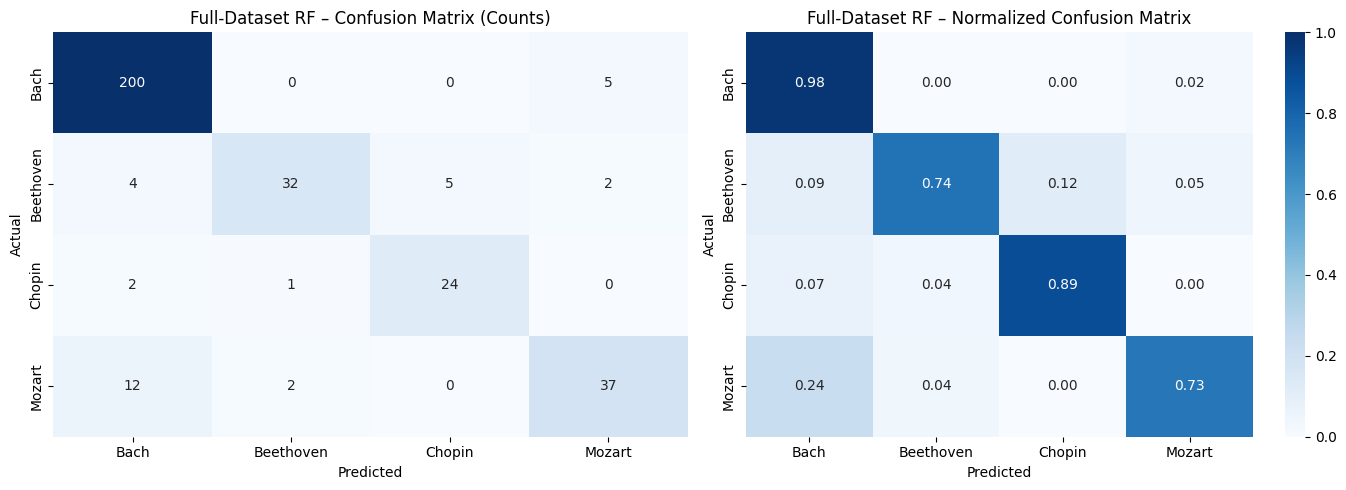

In [ ]:
# Confusion matrices for the full-dataset Random Forest

composers_full = list(full_label_encoder.classes_)   # ['Bach', 'Beethoven', 'Chopin', 'Mozart']
y_true_full = full_label_encoder.inverse_transform(full_y[test_idx])
y_pred_full = full_label_encoder.inverse_transform(rf_pred)

cm_full = confusion_matrix(y_true_full, y_pred_full, labels=composers_full)
cm_full_norm = cm_full.astype(float) / cm_full.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(
    cm_full,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=composers_full,
    yticklabels=composers_full,
    ax=axes[0],
    cbar=False
)
axes[0].set_title("Full-Dataset RF – Confusion Matrix (Counts)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Row-normalized
sns.heatmap(
    cm_full_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=composers_full,
    yticklabels=composers_full,
    ax=axes[1],
    vmin=0.0,
    vmax=1.0
)
axes[1].set_title("Full-Dataset RF – Normalized Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()

# Save
EVAL_DIR = Path("scorematch_artifacts/full_dataset_rf")
EVAL_DIR.mkdir(parents=True, exist_ok=True)
fig_path = EVAL_DIR / "full_dataset_rf_confusion_matrices.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()

### Full Dataset – Random Forest Results

Using all 1,628 valid MIDI files increased Random Forest test accuracy to 0.8988, while macro-F1 reached 0.8506. Although overall accuracy increased, macro-F1 was slightly lower than the 0.8590 achieved on the balanced dataset, showing that the larger Bach class contributed substantially to the higher accuracy. Bach achieved the strongest class-level F1 at 0.9456, while Mozart remained the weakest at 0.7789. Because balanced performance did not improve, the CNN and CNN-LSTM were not retrained on the full imbalanced dataset.



## Conclusion and Future Improvements

On the balanced four-composer dataset, the Random Forest trained on 42 engineered MIDI features produced the strongest overall result, reaching 0.8611 accuracy and 0.8590 macro-F1. The SVM also performed strongly, while the best pure deep-learning configuration was the 15-second CNN with 0.7778 accuracy and 0.7776 macro-F1. The CNN-LSTM performed best with 10-second inputs, stronger augmentation did not improve the CNN, and hybrid CNN-engineered features improved on the pure deep models but did not surpass the strongest classical baselines. The full-dataset Random Forest increased overall accuracy to 0.8988 but did not improve macro-F1 over the balanced experiment.

Future work could evaluate larger balanced MIDI datasets, alternative representations such as spectrograms or sequential note-event inputs, additional CNN and recurrent architectures, and broader hyperparameter optimization. Testing the final models on an independent dataset would also provide a stronger measure of how well composer classification generalizes to music outside the dataset used for training.

Code structure, experimental iterations (augmentation, hybrid features, full-dataset pipeline), and debugging were developed with assistance and recommendations from an AI LLM. Final analysis and conclusions are the authors’ own.